<a href="https://colab.research.google.com/github/ahmedjlidi/Anomaly/blob/main/ALFA_Unsupervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Angus Dempster, Daniel F Schmidt, Geoffrey I Webb

# MiniRocket: A Very Fast (Almost) Deterministic Transform for Time Series
# Classification

# https://arxiv.org/abs/2012.08791

# ** This is a naive extension of MiniRocket to multivariate time series. **

from numba import njit, prange, vectorize
import numpy as np


@njit("float32[:](float32[:,:,:],int32[:],int32[:],int32[:],int32[:],float32[:])", fastmath = True, parallel = False)
def _fit_biases(X, num_channels_per_combination, channel_indices, dilations, num_features_per_dilation, quantiles):

    num_examples, num_channels, input_length = X.shape

    # equivalent to:
    # >>> from itertools import combinations
    # >>> indices = np.array([_ for _ in combinations(np.arange(9), 3)], dtype = np.int32)
    indices = np.array((
        0,1,2,0,1,3,0,1,4,0,1,5,0,1,6,0,1,7,0,1,8,
        0,2,3,0,2,4,0,2,5,0,2,6,0,2,7,0,2,8,0,3,4,
        0,3,5,0,3,6,0,3,7,0,3,8,0,4,5,0,4,6,0,4,7,
        0,4,8,0,5,6,0,5,7,0,5,8,0,6,7,0,6,8,0,7,8,
        1,2,3,1,2,4,1,2,5,1,2,6,1,2,7,1,2,8,1,3,4,
        1,3,5,1,3,6,1,3,7,1,3,8,1,4,5,1,4,6,1,4,7,
        1,4,8,1,5,6,1,5,7,1,5,8,1,6,7,1,6,8,1,7,8,
        2,3,4,2,3,5,2,3,6,2,3,7,2,3,8,2,4,5,2,4,6,
        2,4,7,2,4,8,2,5,6,2,5,7,2,5,8,2,6,7,2,6,8,
        2,7,8,3,4,5,3,4,6,3,4,7,3,4,8,3,5,6,3,5,7,
        3,5,8,3,6,7,3,6,8,3,7,8,4,5,6,4,5,7,4,5,8,
        4,6,7,4,6,8,4,7,8,5,6,7,5,6,8,5,7,8,6,7,8
    ), dtype = np.int32).reshape(84, 3)

    num_kernels = len(indices)
    num_dilations = len(dilations)

    num_features = num_kernels * np.sum(num_features_per_dilation)

    biases = np.zeros(num_features, dtype = np.float32)

    feature_index_start = 0

    combination_index = 0
    num_channels_start = 0

    for dilation_index in range(num_dilations):

        dilation = dilations[dilation_index]
        padding = ((9 - 1) * dilation) // 2

        num_features_this_dilation = num_features_per_dilation[dilation_index]

        for kernel_index in range(num_kernels):

            feature_index_end = feature_index_start + num_features_this_dilation

            num_channels_this_combination = num_channels_per_combination[combination_index]

            num_channels_end = num_channels_start + num_channels_this_combination

            channels_this_combination = channel_indices[num_channels_start:num_channels_end]

            _X = X[np.random.randint(num_examples)][channels_this_combination]

            A = -_X          # A = alpha * X = -X
            G = _X + _X + _X # G = gamma * X = 3X

            C_alpha = np.zeros((num_channels_this_combination, input_length), dtype = np.float32)
            C_alpha[:] = A

            C_gamma = np.zeros((9, num_channels_this_combination, input_length), dtype = np.float32)
            C_gamma[9 // 2] = G

            start = dilation
            end = input_length - padding

            for gamma_index in range(9 // 2):

                C_alpha[:, -end:] = C_alpha[:, -end:] + A[:, :end]
                C_gamma[gamma_index, :, -end:] = G[:, :end]

                end += dilation

            for gamma_index in range(9 // 2 + 1, 9):

                C_alpha[:, :-start] = C_alpha[:, :-start] + A[:, start:]
                C_gamma[gamma_index, :, :-start] = G[:, start:]

                start += dilation

            index_0, index_1, index_2 = indices[kernel_index]

            C = C_alpha + C_gamma[index_0] + C_gamma[index_1] + C_gamma[index_2]
            C = np.sum(C, axis = 0)

            biases[feature_index_start:feature_index_end] = np.quantile(C, quantiles[feature_index_start:feature_index_end])

            feature_index_start = feature_index_end

            combination_index += 1
            num_channels_start = num_channels_end

    return biases

def _fit_dilations(input_length, num_features, max_dilations_per_kernel):

    num_kernels = 84

    num_features_per_kernel = num_features // num_kernels
    true_max_dilations_per_kernel = min(num_features_per_kernel, max_dilations_per_kernel)
    multiplier = num_features_per_kernel / true_max_dilations_per_kernel

    max_exponent = np.log2((input_length - 1) / (9 - 1))
    dilations, num_features_per_dilation = \
    np.unique(np.logspace(0, max_exponent, true_max_dilations_per_kernel, base = 2).astype(np.int32), return_counts = True)
    num_features_per_dilation = (num_features_per_dilation * multiplier).astype(np.int32) # this is a vector

    remainder = num_features_per_kernel - np.sum(num_features_per_dilation)
    i = 0
    while remainder > 0:
        num_features_per_dilation[i] += 1
        remainder -= 1
        i = (i + 1) % len(num_features_per_dilation)

    return dilations, num_features_per_dilation

# low-discrepancy sequence to assign quantiles to kernel/dilation combinations
def _quantiles(n):
    return np.array([(_ * ((np.sqrt(5) + 1) / 2)) % 1 for _ in range(1, n + 1)], dtype = np.float32)

def fit(X, num_features = 10_000, max_dilations_per_kernel = 32):

    _, num_channels, input_length = X.shape

    num_kernels = 84

    dilations, num_features_per_dilation = _fit_dilations(input_length, num_features, max_dilations_per_kernel)

    num_features_per_kernel = np.sum(num_features_per_dilation)

    quantiles = _quantiles(num_kernels * num_features_per_kernel)

    num_dilations = len(dilations)
    num_combinations = num_kernels * num_dilations

    max_num_channels = min(num_channels, 9)
    max_exponent = np.log2(max_num_channels + 1)

    num_channels_per_combination = (2 ** np.random.uniform(0, max_exponent, num_combinations)).astype(np.int32)

    channel_indices = np.zeros(num_channels_per_combination.sum(), dtype = np.int32)

    num_channels_start = 0
    for combination_index in range(num_combinations):
        num_channels_this_combination = num_channels_per_combination[combination_index]
        num_channels_end = num_channels_start + num_channels_this_combination
        channel_indices[num_channels_start:num_channels_end] = np.random.choice(num_channels, num_channels_this_combination, replace = False)

        num_channels_start = num_channels_end

    biases = _fit_biases(X, num_channels_per_combination, channel_indices, dilations, num_features_per_dilation, quantiles)

    return num_channels_per_combination, channel_indices, dilations, num_features_per_dilation, biases

# _PPV(C, b).mean() returns PPV for vector C (convolution output) and scalar b (bias)
# @vectorize("float32(float32,float32)", nopython = True, cache = True)
from numba import vectorize

@vectorize(["float32(float32, float32)"])
def _PPV(a, b):
    return 1.0 if a > b else 0.0

@njit("float32[:,:](float32[:,:,:],Tuple((int32[:],int32[:],int32[:],int32[:],float32[:])))", fastmath = True, parallel = True)
def transform(X, parameters):

    num_examples, num_channels, input_length = X.shape

    num_channels_per_combination, channel_indices, dilations, num_features_per_dilation, biases = parameters

    # equivalent to:
    # >>> from itertools import combinations
    # >>> indices = np.array([_ for _ in combinations(np.arange(9), 3)], dtype = np.int32)
    indices = np.array((
        0,1,2,0,1,3,0,1,4,0,1,5,0,1,6,0,1,7,0,1,8,
        0,2,3,0,2,4,0,2,5,0,2,6,0,2,7,0,2,8,0,3,4,
        0,3,5,0,3,6,0,3,7,0,3,8,0,4,5,0,4,6,0,4,7,
        0,4,8,0,5,6,0,5,7,0,5,8,0,6,7,0,6,8,0,7,8,
        1,2,3,1,2,4,1,2,5,1,2,6,1,2,7,1,2,8,1,3,4,
        1,3,5,1,3,6,1,3,7,1,3,8,1,4,5,1,4,6,1,4,7,
        1,4,8,1,5,6,1,5,7,1,5,8,1,6,7,1,6,8,1,7,8,
        2,3,4,2,3,5,2,3,6,2,3,7,2,3,8,2,4,5,2,4,6,
        2,4,7,2,4,8,2,5,6,2,5,7,2,5,8,2,6,7,2,6,8,
        2,7,8,3,4,5,3,4,6,3,4,7,3,4,8,3,5,6,3,5,7,
        3,5,8,3,6,7,3,6,8,3,7,8,4,5,6,4,5,7,4,5,8,
        4,6,7,4,6,8,4,7,8,5,6,7,5,6,8,5,7,8,6,7,8
    ), dtype = np.int32).reshape(84, 3)

    num_kernels = len(indices)
    num_dilations = len(dilations)

    num_features = num_kernels * np.sum(num_features_per_dilation)

    features = np.zeros((num_examples, num_features), dtype = np.float32)

    for example_index in prange(num_examples):

        _X = X[example_index]

        A = -_X          # A = alpha * X = -X
        G = _X + _X + _X # G = gamma * X = 3X

        feature_index_start = 0

        combination_index = 0
        num_channels_start = 0

        for dilation_index in range(num_dilations):

            _padding0 = dilation_index % 2

            dilation = dilations[dilation_index]
            padding = ((9 - 1) * dilation) // 2

            num_features_this_dilation = num_features_per_dilation[dilation_index]

            C_alpha = np.zeros((num_channels, input_length), dtype = np.float32)
            C_alpha[:] = A

            C_gamma = np.zeros((9, num_channels, input_length), dtype = np.float32)
            C_gamma[9 // 2] = G

            start = dilation
            end = input_length - padding

            for gamma_index in range(9 // 2):

                C_alpha[:, -end:] = C_alpha[:, -end:] + A[:, :end]
                C_gamma[gamma_index, :, -end:] = G[:, :end]

                end += dilation

            for gamma_index in range(9 // 2 + 1, 9):

                C_alpha[:, :-start] = C_alpha[:, :-start] + A[:, start:]
                C_gamma[gamma_index, :, :-start] = G[:, start:]

                start += dilation

            for kernel_index in range(num_kernels):

                feature_index_end = feature_index_start + num_features_this_dilation

                num_channels_this_combination = num_channels_per_combination[combination_index]

                num_channels_end = num_channels_start + num_channels_this_combination

                channels_this_combination = channel_indices[num_channels_start:num_channels_end]

                _padding1 = (_padding0 + kernel_index) % 2

                index_0, index_1, index_2 = indices[kernel_index]

                C = C_alpha[channels_this_combination] + \
                    C_gamma[index_0][channels_this_combination] + \
                    C_gamma[index_1][channels_this_combination] + \
                    C_gamma[index_2][channels_this_combination]
                C = np.sum(C, axis = 0)

                if _padding1 == 0:
                    for feature_count in range(num_features_this_dilation):
                        features[example_index, feature_index_start + feature_count] = _PPV(C, biases[feature_index_start + feature_count]).mean()
                else:
                    for feature_count in range(num_features_this_dilation):
                        features[example_index, feature_index_start + feature_count] = _PPV(C[padding:-padding], biases[feature_index_start + feature_count]).mean()

                feature_index_start = feature_index_end

                combination_index += 1
                num_channels_start = num_channels_end

    return features



from numba import cuda
import numpy as np
import math

@cuda.jit
def transform_gpu(X, num_channels_per_combination, channel_indices,
                  dilations, num_features_per_dilation, biases, features, indices):

    example_index = cuda.grid(1)  # one thread per example

    if example_index >= X.shape[0]:
        return

    num_examples, num_channels, input_length = X.shape
    num_kernels = 84
    num_dilations = len(dilations)

    # Each thread handles one example independently
    # (same logic as your prange loop body)
    feature_index_start = 0
    combination_index = 0
    num_channels_start = 0

    for dilation_index in range(num_dilations):
        _padding0 = dilation_index % 2
        dilation = dilations[dilation_index]
        padding = ((9 - 1) * dilation) // 2
        num_features_this_dilation = num_features_per_dilation[dilation_index]

        for kernel_index in range(num_kernels):
            feature_index_end = feature_index_start + num_features_this_dilation
            num_channels_this_combination = num_channels_per_combination[combination_index]
            num_channels_end = num_channels_start + num_channels_this_combination
            _padding1 = (_padding0 + kernel_index) % 2
            index_0 = indices[kernel_index, 0]
            index_1 = indices[kernel_index, 1]
            index_2 = indices[kernel_index, 2]

            for feature_count in range(num_features_this_dilation):
                C_sum = 0.0
                count = 0

                start_i = padding if _padding1 != 0 else 0
                end_i = input_length - padding if _padding1 != 0 else input_length

                for i in range(start_i, end_i):
                    val = 0.0
                    for ch_offset in range(num_channels_this_combination):
                        ch = channel_indices[num_channels_start + ch_offset]
                        # Inline the convolution: alpha + gamma terms
                        a = -X[example_index, ch, i]
                        g = X[example_index, ch, i] * 3.0

                        c = a  # C_alpha base
                        # Add shifted alpha terms
                        for k in range(9 // 2):
                            shift = (k + 1) * dilation
                            if i + shift < input_length:
                                c += -X[example_index, ch, i + shift]
                            if i - shift >= 0:
                                c += -X[example_index, ch, i - shift]

                        # Add gamma terms for the three indices
                        for gidx, g_kernel_index in enumerate((index_0, index_1, index_2)):
                            offset = (g_kernel_index - 4) * dilation  # center is 4
                            j = i - offset
                            if 0 <= j < input_length:
                                c += X[example_index, ch, j] * 3.0

                        val += c

                    if val > biases[feature_index_start + feature_count]:
                        C_sum += 1.0
                    count += 1

                if count > 0:
                    features[example_index, feature_index_start + feature_count] = C_sum / count

            feature_index_start = feature_index_end
            combination_index += 1
            num_channels_start = num_channels_end


def transform_with_gpu(X, parameters):
    num_channels_per_combination, channel_indices, dilations, num_features_per_dilation, biases = parameters

    indices = np.array((
        0,1,2,0,1,3,0,1,4,0,1,5,0,1,6,0,1,7,0,1,8,
        # ... same indices array as original ...
    ), dtype=np.int32).reshape(84, 3)

    num_examples = X.shape[0]
    num_features = 84 * np.sum(num_features_per_dilation)
    features = np.zeros((num_examples, num_features), dtype=np.float32)

    # Move to GPU
    X_d          = cuda.to_device(X)
    ncpc_d       = cuda.to_device(num_channels_per_combination)
    ci_d         = cuda.to_device(channel_indices)
    dil_d        = cuda.to_device(dilations)
    nfpd_d       = cuda.to_device(num_features_per_dilation)
    bias_d       = cuda.to_device(biases)
    feat_d       = cuda.to_device(features)
    idx_d        = cuda.to_device(indices)

    # Launch: one thread per example
    threads_per_block = 64
    blocks = math.ceil(num_examples / threads_per_block)

    transform_gpu[blocks, threads_per_block](
        X_d, ncpc_d, ci_d, dil_d, nfpd_d, bias_d, feat_d, idx_d
    )

    return feat_d.copy_to_host()

In [ ]:
import numpy as np

NUM_KERNELS = 84

def kernel_feature_columns(num_features_per_dilation, num_kernels=NUM_KERNELS):
    """
    Returns: list cols_by_kernel of length 84.
    cols_by_kernel[k] is an int array of ALL feature column indices produced by kernel k
    across all dilations.
    """
    num_features_per_dilation = np.asarray(num_features_per_dilation, dtype=int)

    cols_by_kernel = [[] for _ in range(num_kernels)]
    offset = 0
    for Fd in num_features_per_dilation:
        # block layout: [kernel0 Fd feats][kernel1 Fd feats]...[kernel83 Fd feats]
        for k in range(num_kernels):
            start = offset + k * Fd
            end = start + Fd
            cols_by_kernel[k].append(np.arange(start, end, dtype=np.int32))
        offset += num_kernels * Fd

    return [np.concatenate(parts) for parts in cols_by_kernel]


def kernel_signatures(Z, num_features_per_dilation):
    """
    Z: (N, D_full) MiniRocket features from transform_full
    Returns S: (N, 84) where S[:, k] summarizes kernel k for each sample.
    """
    cols_by_kernel = kernel_feature_columns(num_features_per_dilation)
    N = Z.shape[0]
    S = np.zeros((N, NUM_KERNELS), dtype=np.float32)

    for k in range(NUM_KERNELS):
        cols = cols_by_kernel[k]
        S[:, k] = Z[:, cols].mean(axis=1)  # scalar per sample

    return S


def _pearson_corr(a, b, eps=1e-12):
    a = a.astype(np.float64)
    b = b.astype(np.float64)
    a = a - a.mean()
    b = b - b.mean()
    den = (np.sqrt((a*a).sum()) * np.sqrt((b*b).sum())) + eps
    return float((a*b).sum() / den)

def kernel_fisher_scores(S, y, eps=1e-12):
    """
    S: (N, 84) kernel signatures
    y: (N,) labels
    Returns scores: (84,)
    """
    y = np.asarray(y)
    classes = np.unique(y)
    scores = np.zeros(NUM_KERNELS, dtype=np.float64)

    for k in range(NUM_KERNELS):
        s = S[:, k].astype(np.float64)
        mu = s.mean()
        num = 0.0
        den = 0.0
        for c in classes:
            sc = s[y == c]
            if sc.size == 0:
                continue
            muc = sc.mean()
            num += sc.size * (muc - mu) ** 2
            den += ((sc - muc) ** 2).sum()
        scores[k] = num / (den + eps)
    return scores

def prune_correlated_kernels(S, y=None, tau=0.95, method="fisher"):
    """
    S: (N, 84) kernel signatures
    tau: correlation threshold, use abs(corr) >= tau as redundant
    method: 'fisher' (needs y) or 'variance'

    Returns kept_kernels (int32 sorted by relevance order).
    """
    if method == "fisher":
        if y is None:
            raise ValueError("method='fisher' requires labels y")
        scores = kernel_fisher_scores(S, y)
    elif method == "variance":
        scores = S.var(axis=0)
    else:
        raise ValueError("method must be 'fisher' or 'variance'")

    order = np.argsort(scores)[::-1]  # high to low
    kept = []

    for k in order:
        ok = True
        for j in kept:
            if abs(_pearson_corr(S[:, k], S[:, j])) >= tau:
                ok = False
                break
        if ok:
            kept.append(int(k))

    return np.array(kept, dtype=np.int32)



def kept_kernel_feature_cols(kept_kernels, num_features_per_dilation, num_kernels=84):
    cols_by_kernel = kernel_feature_columns(num_features_per_dilation, num_kernels=num_kernels)
    kept_cols = np.concatenate([cols_by_kernel[int(k)] for k in kept_kernels]).astype(np.int32)
    kept_cols.sort()
    return kept_cols



In [ ]:
!pip install aeon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 19.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ============================================================
# CONFIG
# ============================================================
ROOT_FOLDER = "FaultDetection_ALFA-Dataset-master/failures"
OUT_DIR = "FaultDetection_ALFA-Dataset-master/failures/laplacian_selected_multiclass"

WINDOW_SIZE = 10
STRIDE = 5
TEST_SIZE = 0.2
RANDOM_STATE = 0

# raw feature selection
TOP_K_RAW_FEATURES = 12
LAPLACIAN_SAMPLE_ROWS = 20000
LAPLACIAN_KNN = 5
HEAT_T = 1.0

# stats to compute after raw-column selection
TIME_STATS = [
    "p50",
    "iqr",
    "rms",
    "slope",
    "mean_abs_diff",
]

FFT_STATS = [
    "mean", "p25", "p50", "p75"
]

# metadata columns to ignore from raw features
TIME_COL = "%time"
FILE_COL = "source_file"
FOLDER_COL = "source_folder"
LABEL_SOURCE_COL = "field.data"

# explicitly allow these no_failure files even if field.data is missing
FORCE_ALLOW_NO_FAILURE = {
    "carbonZ_2018-07-18-16-37-39_1_no_failure.csv",
    "carbonZ_2018-07-30-16-39-00_3_no_failure.csv",
    "carbonZ_2018-09-11-14-16-55_no_failure.csv",
    "carbonZ_2018-09-11-14-41-38_no_failure.csv",
    "carbonZ_2018-09-11-15-05-11_2_no_failure.csv",
    "carbonZ_2018-10-05-14-34-20_1_no_failure.csv",
    "carbonZ_2018-10-05-14-37-22_1_no_failure.csv",
    "carbonZ_2018-10-05-15-52-12_1_no_failure.csv",
    "carbonZ_2018-10-05-15-52-12_2_no_failure.csv",
}

# ============================================================
# BASIC STATS
# ============================================================
def calculate_mean(x):
    return float(np.mean(x))

def calculate_variance(x):
    return float(np.var(x))

def calculate_rms(x):
    return float(np.sqrt(np.mean(x ** 2)))

def calculate_p25(x):
    return float(np.quantile(x, 0.25))

def calculate_p50(x):
    return float(np.quantile(x, 0.50))

def calculate_p75(x):
    return float(np.quantile(x, 0.75))

def calculate_iqr(x):
    return float(np.quantile(x, 0.75) - np.quantile(x, 0.25))

def calculate_slope(x):
    if len(x) < 2:
        return 0.0
    t = np.arange(len(x), dtype=np.float64)
    t_mean = np.mean(t)
    x_mean = np.mean(x)
    denom = np.sum((t - t_mean) ** 2)
    if denom == 0:
        return 0.0
    return float(np.sum((t - t_mean) * (x - x_mean)) / denom)

def calculate_mean_abs_diff(x):
    if len(x) < 2:
        return 0.0
    return float(np.mean(np.abs(np.diff(x))))

def fft_magnitude(x):
    f = np.fft.rfft(x.astype(np.float64))
    mag = np.abs(f)
    return mag.astype(np.float64)

def calc_stat(x, stat_name):
    if stat_name == "mean":
        return calculate_mean(x)
    elif stat_name == "variance":
        return calculate_variance(x)
    elif stat_name == "rms":
        return calculate_rms(x)
    elif stat_name == "p25":
        return calculate_p25(x)
    elif stat_name == "p50":
        return calculate_p50(x)
    elif stat_name == "p75":
        return calculate_p75(x)
    elif stat_name == "iqr":
        return calculate_iqr(x)
    elif stat_name == "slope":
        return calculate_slope(x)
    elif stat_name == "mean_abs_diff":
        return calculate_mean_abs_diff(x)
    else:
        raise ValueError(f"Unknown stat: {stat_name}")

# ============================================================
# LAPLACIAN SCORE
# lower is better
# ============================================================
def laplacian_score(X, n_neighbors=5, heat_t=1.0, eps=1e-12):
    n_samples, n_features = X.shape

    nn = NearestNeighbors(n_neighbors=min(n_neighbors + 1, n_samples), metric="euclidean")
    nn.fit(X)
    dists, inds = nn.kneighbors(X)

    W = np.zeros((n_samples, n_samples), dtype=np.float64)

    for i in range(n_samples):
        for j_pos in range(1, inds.shape[1]):
            j = inds[i, j_pos]
            dist = dists[i, j_pos]
            w = np.exp(-(dist ** 2) / max(heat_t, eps))
            W[i, j] = max(W[i, j], w)
            W[j, i] = max(W[j, i], w)

    D = np.diag(W.sum(axis=1))
    L = D - W
    d_vec = np.diag(D)

    scores = np.zeros(n_features, dtype=np.float64)

    for r in range(n_features):
        f = X[:, r].astype(np.float64)
        denom_d = d_vec.sum() + eps
        mu = np.sum(d_vec * f) / denom_d
        f_tilde = f - mu

        num = f_tilde.T @ L @ f_tilde
        den = f_tilde.T @ D @ f_tilde

        scores[r] = num / (den + eps)

    return scores

# ============================================================
# STEP 1: SCAN RAW COLUMNS
# ============================================================
all_rows = []
candidate_cols = None

for folder_name in sorted(os.listdir(ROOT_FOLDER)):
    folder_path = os.path.join(ROOT_FOLDER, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for file in sorted(os.listdir(folder_path)):
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)

        force_allow = (folder_name == "no_failure" and file in FORCE_ALLOW_NO_FAILURE)

        if LABEL_SOURCE_COL not in df.columns and not force_allow:
            continue

        if candidate_cols is None:
            candidate_cols = [
                c for c in df.columns
                if c not in [TIME_COL, LABEL_SOURCE_COL, "label", "delta_roll_airspeed"]
                and pd.api.types.is_numeric_dtype(df[c])
            ]

        keep = [c for c in candidate_cols if c in df.columns]
        sub = df[keep].copy()
        sub = sub.apply(pd.to_numeric, errors="coerce")

        sub = sub.replace([np.inf, -np.inf], np.nan)
        sub = sub.dropna()

        if len(sub) == 0:
            continue

        all_rows.append(sub)

if len(all_rows) == 0:
    raise ValueError("No usable raw rows found.")

raw_df = pd.concat(all_rows, axis=0, ignore_index=True)

valid_cols = []
for c in raw_df.columns:
    if raw_df[c].nunique() > 1:
        valid_cols.append(c)

raw_df = raw_df[valid_cols].copy()

if len(raw_df) > LAPLACIAN_SAMPLE_ROWS:
    raw_df = raw_df.sample(n=LAPLACIAN_SAMPLE_ROWS, random_state=0)

X_lap = raw_df.to_numpy(dtype=np.float64)

scaler = StandardScaler()
X_lap = scaler.fit_transform(X_lap)

scores = laplacian_score(
    X_lap,
    n_neighbors=LAPLACIAN_KNN,
    heat_t=HEAT_T
)

lap_df = pd.DataFrame({
    "feature": raw_df.columns,
    "laplacian_score": scores
}).sort_values("laplacian_score", ascending=True).reset_index(drop=True)

selected_raw_cols = lap_df["feature"].iloc[:TOP_K_RAW_FEATURES].tolist()

print("[INFO] Top raw columns by Laplacian score:")
print(lap_df.head(TOP_K_RAW_FEATURES))

# ============================================================
# STEP 2: BUILD FEATURE TABLE USING SELECTED RAW COLUMNS
# ============================================================
rows = []

for folder_name in sorted(os.listdir(ROOT_FOLDER)):
    folder_path = os.path.join(ROOT_FOLDER, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for file in sorted(os.listdir(folder_path)):
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)

        force_allow = (folder_name == "no_failure" and file in FORCE_ALLOW_NO_FAILURE)

        if LABEL_SOURCE_COL not in df.columns and not force_allow:
            continue

        df = df.dropna().copy()

        if LABEL_SOURCE_COL in df.columns:
            df["label"] = pd.to_numeric(df[LABEL_SOURCE_COL], errors="coerce")
            df = df.dropna(subset=["label"])
            df["label"] = df["label"].astype(int)
            df = df.drop(columns=[LABEL_SOURCE_COL])
        else:
            # explicitly allowed no_failure files
            df["label"] = 0

        if "delta_roll_airspeed" in df.columns:
            df = df.drop(columns=["delta_roll_airspeed"])

        present_cols = [c for c in selected_raw_cols if c in df.columns]
        if len(present_cols) == 0:
            continue

        if len(df) < WINDOW_SIZE:
            continue

        starts = np.arange(0, len(df) - WINDOW_SIZE + 1, STRIDE, dtype=int)

        for st in starts:
            box = df.iloc[st:st + WINDOW_SIZE].copy()
            feat_row = {}

            for col in present_cols:
                x = pd.to_numeric(box[col], errors="coerce").dropna().to_numpy(dtype=np.float64)

                if len(x) == 0:
                    for s in TIME_STATS:
                        feat_row[f"{col}_{s}"] = 0.0
                    for s in FFT_STATS:
                        feat_row[f"{col}_fft_{s}"] = 0.0
                    continue

                for s in TIME_STATS:
                    feat_row[f"{col}_{s}"] = calc_stat(x, s)

                x_fft = fft_magnitude(x)
                for s in FFT_STATS:
                    feat_row[f"{col}_fft_{s}"] = calc_stat(x_fft, s)

            vals, counts = np.unique(box["label"].to_numpy(), return_counts=True)
            majority_label = int(vals[np.argmax(counts)])

            feat_row["label"] = majority_label
            feat_row["source_folder"] = folder_name
            feat_row["source_file"] = file
            feat_row["start_row"] = int(st)
            feat_row["end_row"] = int(st + WINDOW_SIZE - 1)

            rows.append(feat_row)

feature_df = pd.DataFrame(rows)

if len(feature_df) == 0:
    raise ValueError("No feature rows were created.")

print("\n[INFO] Final feature table shape:", feature_df.shape)
print("[INFO] Label counts:")
print(feature_df["label"].value_counts().sort_index())

# ============================================================
# SAVE
# ============================================================
os.makedirs(OUT_DIR, exist_ok=True)

feature_df.to_csv(os.path.join(OUT_DIR, "laplacian_selected_feature_table_multiclass.csv"), index=False)
lap_df.to_csv(os.path.join(OUT_DIR, "laplacian_scores_raw_columns.csv"), index=False)

print("\n[OK] Saved:")
print(os.path.join(OUT_DIR, "laplacian_selected_feature_table_multiclass.csv"))
print(os.path.join(OUT_DIR, "laplacian_scores_raw_columns.csv"))

# ============================================================
# QUICK TRAIN/TEST SPLIT PREP
# ============================================================
feature_cols_final = [
    c for c in feature_df.columns
    if c not in ["label", "source_folder", "source_file", "start_row", "end_row"]
]

X = feature_df[feature_cols_final].to_numpy(dtype=np.float32)
y = feature_df["label"].to_numpy(dtype=np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train label counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test label counts :", dict(zip(*np.unique(y_test, return_counts=True))))


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
# from aeon.classification.convolution_based import MiniRocketClassifier

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = "FaultDetection_ALFA-Dataset-master/failures/laplacian_selected_multiclass/laplacian_selected_feature_table_multiclass.csv"
OUT_DIR = "FaultDetection_ALFA-Dataset-master/failures/laplacian_windowed_for_minirocket"

LABEL_COL = "label"
FILE_COL = "source_file"

# second-stage windowing over the aggregated/statistical rows
WINDOW_ROWS = 40
STRIDE = 1

NORMALIZE_01 = False
TEST_SIZE = 0.2
RANDOM_STATE = 0

# ============================================================
# LOAD
# ============================================================
df = pd.read_csv(CSV_PATH)

required_cols = [LABEL_COL, FILE_COL]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

meta_cols = {"label", "source_file", "source_folder", "start_row", "end_row"}
feature_cols = [c for c in df.columns if c not in meta_cols]

if len(feature_cols) == 0:
    raise ValueError("No feature columns found after removing metadata.")

print("Input table shape:", df.shape)
print("Num feature columns:", len(feature_cols))
print("Num files:", df[FILE_COL].nunique())
print("Classes:", dict(zip(*np.unique(df[LABEL_COL], return_counts=True))))

# ============================================================
# OPTIONAL NORMALIZATION ON THE FEATURE TABLE
# ============================================================
if NORMALIZE_01:
    scaler = MinMaxScaler()
    df[feature_cols] = scaler.fit_transform(df[feature_cols])

# ============================================================
# SECOND-STAGE WINDOWING INSIDE EACH FILE
# each sample becomes (C, T)
# ============================================================
X_list = []
y_list = []
meta_rows = []

for fname in df[FILE_COL].astype(str).unique():
    sub = df[df[FILE_COL].astype(str) == fname].copy().reset_index(drop=True)

    if len(sub) < WINDOW_ROWS:
        continue

    X_raw = sub[feature_cols].to_numpy(dtype=np.float32)   # (rows, C)
    y_raw = sub[LABEL_COL].to_numpy()

    for start in range(0, len(sub) - WINDOW_ROWS + 1, STRIDE):
        end = start + WINDOW_ROWS

        block_x = X_raw[start:end]   # (WINDOW_ROWS, C)
        block_y = y_raw[start:end]

        # convert to (C, T) for MiniRocket multivariate
        X_ct = block_x.T

        # majority label
        vals, counts = np.unique(block_y, return_counts=True)
        y_win = vals[np.argmax(counts)]

        X_list.append(X_ct)
        y_list.append(y_win)

        meta_rows.append({
            "source_file": fname,
            "start_idx": int(start),
            "end_idx": int(end - 1),
            "start_row_global": int(sub.iloc[start]["start_row"]) if "start_row" in sub.columns else start,
            "end_row_global": int(sub.iloc[end - 1]["end_row"]) if "end_row" in sub.columns else end - 1,
            "label": int(y_win),
        })

if len(X_list) == 0:
    raise ValueError("No second-stage windows were created.")

X = np.stack(X_list, axis=0).astype(np.float32)   # (N, C, T)
y = np.array(y_list, dtype=np.int64)
meta_df = pd.DataFrame(meta_rows)

print("Windowed X shape:", X.shape)
print("Windowed y shape:", y.shape)
print("Windowed label counts:", dict(zip(*np.unique(y, return_counts=True))))

# ============================================================
# SAVE WINDOWED DATA
# ============================================================
os.makedirs(OUT_DIR, exist_ok=True)

np.save(f"{OUT_DIR}/X_laplacian_second_window.npy", X)
np.save(f"{OUT_DIR}/y_laplacian_second_window.npy", y)
meta_df.to_csv(f"{OUT_DIR}/meta_laplacian_second_window.csv", index=False)

print("[OK] Saved:")
print(f" - {OUT_DIR}/X_laplacian_second_window.npy")
print(f" - {OUT_DIR}/y_laplacian_second_window.npy")
print(f" - {OUT_DIR}/meta_laplacian_second_window.csv")



import numpy as np
from sklearn.model_selection import train_test_split

# ============================================================
# BINARY CONVERSION
# 0 stays normal
# everything else becomes anomaly = 1
# ============================================================
y_bin = (y != 0).astype(np.int64)

print("Binary label counts:", dict(zip(*np.unique(y_bin, return_counts=True))))

# ============================================================
# SPLIT NORMAL ONLY
# 80% normal -> train
# 20% normal -> test
# all anomalies -> test
# ============================================================
normal_idx = np.where(y_bin == 0)[0]
anom_idx = np.where(y_bin == 1)[0]

train_normal_idx, test_normal_idx = train_test_split(
    normal_idx,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_idx = train_normal_idx
test_idx = np.concatenate([test_normal_idx, anom_idx])

X_train = X[train_idx].astype(np.float32)
y_train = y_bin[train_idx]

X_test = X[test_idx].astype(np.float32)
y_test = y_bin[test_idx]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train labels:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Test labels :", dict(zip(*np.unique(y_test, return_counts=True))))

# sanity checks
assert np.all(y_train == 0), "Training set must contain only normal samples."
assert set(np.unique(y_test)).issubset({0, 1}), "Test labels must be binary."



from sklearn.preprocessing import MinMaxScaler

# ============================================================
# SCALE USING TRAIN ONLY
# ============================================================

Ntr, C, T = X_train.shape
Nte = X_test.shape[0]

# flatten to (samples*time, channels)
X_train_flat = X_train.transpose(0,2,1).reshape(-1, C)
X_test_flat  = X_test.transpose(0,2,1).reshape(-1, C)

scaler = MinMaxScaler()

X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat  = scaler.transform(X_test_flat)

# reshape back to (N, C, T)
X_train = X_train_flat.reshape(Ntr, T, C).transpose(0,2,1)
X_test  = X_test_flat.reshape(Nte, T, C).transpose(0,2,1)

print("Scaling complete")

Input table shape: (19066, 113)
Num feature columns: 108
Num files: 45
Classes: {np.int64(0): np.int64(16034), np.int64(1): np.int64(1401), np.int64(2): np.int64(88), np.int64(3): np.int64(1276), np.int64(4): np.int64(267)}
Windowed X shape: (17311, 108, 40)
Windowed y shape: (17311,)
Windowed label counts: {np.int64(0): np.int64(14977), np.int64(1): np.int64(962), np.int64(2): np.int64(48), np.int64(3): np.int64(1137), np.int64(4): np.int64(187)}
[OK] Saved:
 - /content/drive/MyDrive/Dr.Noura/RocketBoost/FaultDetection_ALFA-Dataset-master/failures/laplacian_windowed_for_minirocket/X_laplacian_second_window.npy
 - /content/drive/MyDrive/Dr.Noura/RocketBoost/FaultDetection_ALFA-Dataset-master/failures/laplacian_windowed_for_minirocket/y_laplacian_second_window.npy
 - /content/drive/MyDrive/Dr.Noura/RocketBoost/FaultDetection_ALFA-Dataset-master/failures/laplacian_windowed_for_minirocket/meta_laplacian_second_window.csv
Binary label counts: {np.int64(0): np.int64(14977), np.int64(1): np.

In [ ]:
import numpy as np
from scipy.stats import rankdata

def zscore_safe(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float64)
    return (x - x.mean()) / (x.std() + eps)

def pseudo_snr_scores(X, eps=1e-12):
    """
    X: (N, C, T) normal-only training data
    returns snr: (C,)
    """
    N, C, T = X.shape
    snr = np.zeros(C, dtype=np.float64)

    for c in range(C):
        Xc = X[:, c, :]                 # (N, T)
        mu = Xc.mean(axis=0)            # (T,)
        signal = np.var(mu)
        noise = np.mean((Xc - mu[None, :]) ** 2)
        snr[c] = signal / (noise + eps)

    return snr

def find_elbow_point(sorted_values):
    """
    Given a sorted list in descending order, find the elbow point.
    Returns:
        threshold, elbow_index
    """
    sorted_values = np.asarray(sorted_values, dtype=np.float64)
    n = len(sorted_values)

    if n == 1:
        return float(sorted_values[0]), 0

    all_points = np.vstack((np.arange(n), sorted_values)).T

    first_point = all_points[0]
    last_point = all_points[-1]
    line_vec = last_point - first_point
    line_norm = np.linalg.norm(line_vec)

    if line_norm == 0:
        return float(sorted_values[0]), 0

    line_unitvec = line_vec / line_norm

    distances = []
    for point in all_points:
        vec = point - first_point
        proj = np.dot(vec, line_unitvec)
        proj_point = first_point + proj * line_unitvec
        dist = np.linalg.norm(point - proj_point)
        distances.append(dist)

    distances = np.array(distances)
    elbow_index = int(np.argmax(distances))
    threshold = float(sorted_values[elbow_index])

    return threshold, elbow_index

def spearman_redundancy_scores(X):
    """
    X: (N, C, T)
    returns average absolute Spearman correlation with other channels: (C,)
    """
    N, C, T = X.shape

    # flatten each channel to one long vector
    Xflat = X.transpose(1, 0, 2).reshape(C, -1)   # (C, N*T)

    # rank-transform each channel
    Xrank = np.zeros_like(Xflat, dtype=np.float64)
    for c in range(C):
        Xrank[c] = rankdata(Xflat[c])

    # Pearson on ranks = Spearman
    corr = np.corrcoef(Xrank)
    corr = np.nan_to_num(corr, nan=0.0)

    np.fill_diagonal(corr, 0.0)
    redundancy = np.mean(np.abs(corr), axis=1)

    return redundancy

def unsupervised_channel_scores_snr_spearman(X, beta=1.0):
    """
    X: (N, C, T) normal-only training data

    Score = z(log(1+SNR)) - beta * z(Spearman redundancy)
    """
    snr = pseudo_snr_scores(X)
    red = spearman_redundancy_scores(X)

    snr_z = zscore_safe(np.log1p(snr))
    red_z = zscore_safe(red)

    final_score = snr_z - beta * red_z

    details = {
        "snr": snr,
        "spearman_redundancy": red,
        "snr_z": snr_z,
        "spearman_redundancy_z": red_z,
        "final_score": final_score,
    }

    return final_score, details

def select_channels_unsupervised_snr_spearman_elbow(X_train, beta=1.0):
    """
    X_train: (N, C, T) normal-only train

    returns:
        dropped, kept, scores, details, threshold, elbow_index
    """
    scores, details = unsupervised_channel_scores_snr_spearman(X_train, beta=beta)

    order = np.argsort(scores)[::-1]
    sorted_scores = scores[order]

    threshold, elbow_index = find_elbow_point(sorted_scores)

    kept = order[:elbow_index + 1].tolist()
    dropped = sorted(list(set(range(X_train.shape[1])) - set(kept)))

    return dropped, kept, scores, details, threshold, elbow_index

In [ ]:
dropped_channels, kept_channels, scores, details, threshold, elbow_index = \
    select_channels_unsupervised_snr_spearman_elbow(
        X_train,
        beta=1.0
    )

print("Total channels:", X_train.shape[1])
print("Elbow index:", elbow_index)
print("Threshold:", threshold)
print("Kept channels:", kept_channels)
print("Num kept:", len(kept_channels))
print("Dropped channels:", dropped_channels)
print("Num dropped:", len(dropped_channels))

X_train = X_train[:, kept_channels, :]
X_test  = X_test[:, kept_channels, :]

Total channels: 108
Elbow index: 12
Threshold: 1.3210825456139181
Kept channels: [9, 11, 14, 36, 89, 88, 85, 82, 87, 84, 45, 81, 30]
Num kept: 13
Dropped channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 83, 86, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107]
Num dropped: 95


In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# SETTINGS
# ============================================================
NUM_FEATURES = 1000
MAX_DILATIONS = 32
TAU = 0.7
THRESHOLD_QUANTILE = 0.999
K_NEIGHBORS = 5

# ============================================================
# FIT MINIROCKET ON NORMAL TRAIN ONLY
# ============================================================
params = fit(
    X_train.astype(np.float32),
    num_features=NUM_FEATURES,
    max_dilations_per_kernel=MAX_DILATIONS
)

_, _, dilations, num_features_per_dilation, _ = params

# ============================================================
# TRANSFORM TRAIN / TEST
# ============================================================
Ztr_full = transform(X_train.astype(np.float32), params).astype(np.float32)
Zte_full = transform(X_test.astype(np.float32),  params).astype(np.float32)

print("Full transformed train shape:", Ztr_full.shape)
print("Full transformed test shape :", Zte_full.shape)

# ============================================================
# KERNEL SELECTION USING VARIANCE
# one-class safe
# ============================================================


S = kernel_signatures(Ztr_full, num_features_per_dilation)

kept_kernels = prune_correlated_kernels(
    S,
    y=None,
    tau=TAU,
    method="variance"
)

kept_cols = kept_kernel_feature_cols(
    kept_kernels,
    num_features_per_dilation
)

Ztr = Ztr_full[:, kept_cols]
Zte = Zte_full[:, kept_cols]


print("Kept kernels:", len(kept_kernels))
print("Reduced train shape:", Ztr.shape)
print("Reduced test shape :", Zte.shape)

# ============================================================
# KNN ANOMALY SCORING
# ============================================================
k = min(int(K_NEIGHBORS), max(2, Ztr.shape[0]))
nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
nn.fit(Ztr)

d_train, _ = nn.kneighbors(Ztr)
d_test, _ = nn.kneighbors(Zte)

train_scores = d_train.mean(axis=1).astype(np.float32)
test_scores = d_test.mean(axis=1).astype(np.float32)

# ============================================================
# THRESHOLD FROM TRAIN ONLY
# ============================================================
threshold = np.quantile(train_scores, THRESHOLD_QUANTILE)
y_pred = (test_scores > threshold).astype(np.int64)

# ============================================================
# EVALUATION
# ============================================================
acc = accuracy_score(y_test, y_pred)

print("Threshold:", threshold)
print("Accuracy:", acc)
print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

# ============================================================
# FEATURE REDUCTION REPORT
# ============================================================
D_full = Ztr_full.shape[1]
D_kept = Ztr.shape[1]

print("Full features:", D_full)
print("Kept features:", D_kept)
print("Feature reduction %:", 100 * (1 - D_kept / D_full))

Full transformed train shape: (11981, 924)
Full transformed test shape : (5330, 924)
Kept kernels: 50
Reduced train shape: (11981, 550)
Reduced test shape : (5330, 550)
Threshold: 1.6352037
Accuracy: 0.974671669793621

Classification report:
              precision    recall  f1-score   support

           0     0.9713    0.9840    0.9776      2996
           1     0.9791    0.9627    0.9708      2334

    accuracy                         0.9747      5330
   macro avg     0.9752    0.9734    0.9742      5330
weighted avg     0.9747    0.9747    0.9746      5330

Confusion matrix:
[[2948   48]
 [  87 2247]]
Full features: 924
Kept features: 550
Feature reduction %: 40.476190476190474


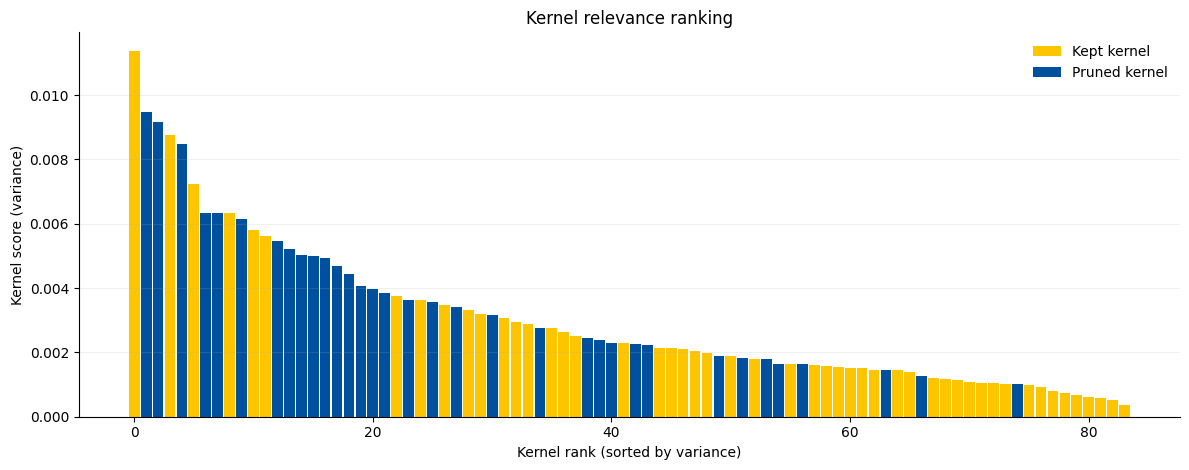

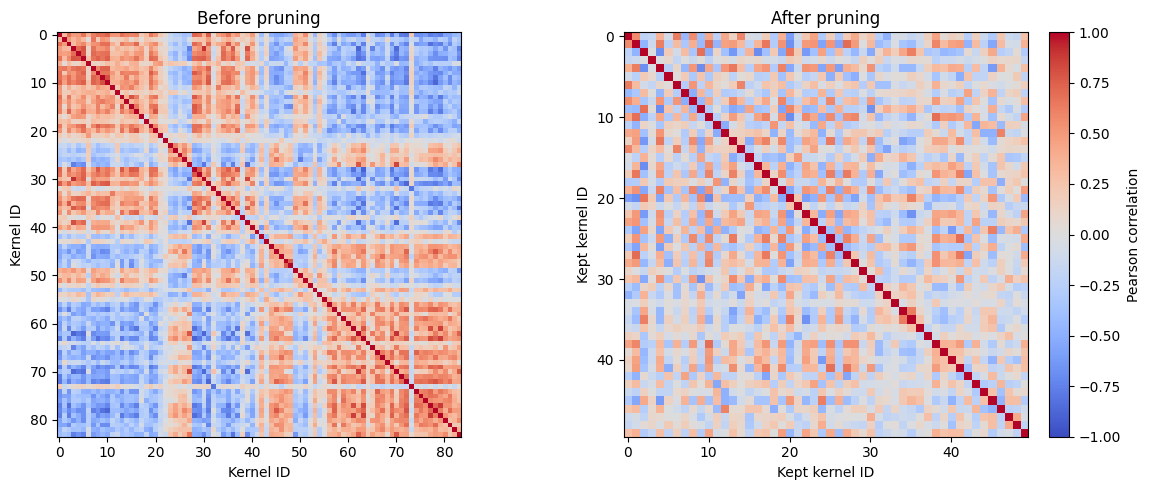

Mean |corr| before: 0.32953611135470373
Mean |corr| after : 0.24099613207798404
Num kept kernels  : 50


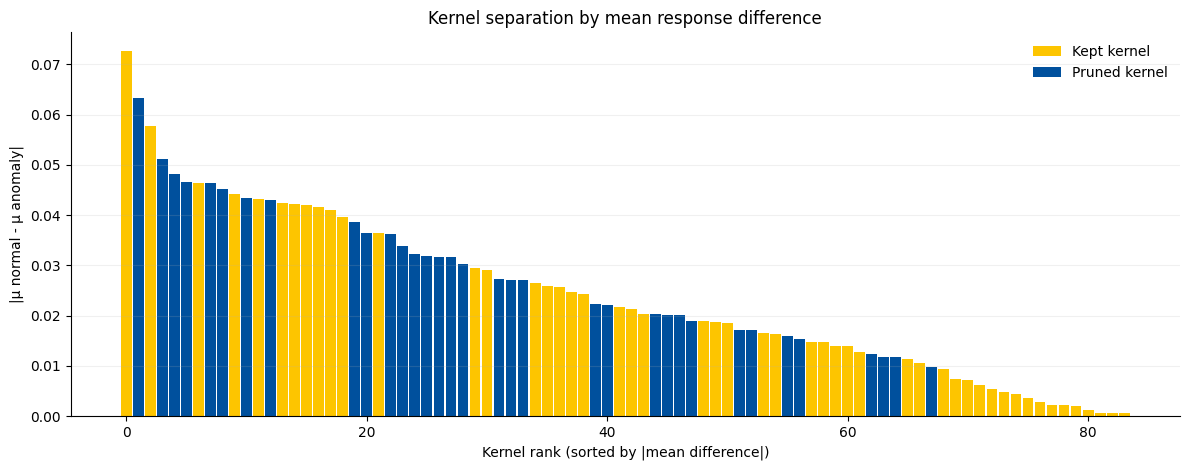

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ============================================================
# OPTIONAL: recompute kept_kernels if not already available
# ============================================================
# S_train = kernel_signatures(Ztr_full, num_features_per_dilation)
# kept_kernels = prune_correlated_kernels(
#     S_train,
#     y=None,
#     tau=TAU,
#     method="variance"
# )

# ============================================================
# BUILD KERNEL SIGNATURES
# ============================================================
S_train = kernel_signatures(Ztr_full, num_features_per_dilation)   # (N_train, 84)
S_test  = kernel_signatures(Zte_full, num_features_per_dilation)   # (N_test, 84)

# kernel relevance score used by your method
kernel_scores = S_train.var(axis=0).astype(np.float64)

NUM_KERNELS = S_train.shape[1]
all_kernel_ids = np.arange(NUM_KERNELS)

kept_mask = np.zeros(NUM_KERNELS, dtype=bool)
kept_mask[np.asarray(kept_kernels, dtype=int)] = True


# ============================================================
# FIGURE 1: SORTED KERNEL SCORE PLOT
# ============================================================
def plot_kernel_score_ranking(kernel_scores, kept_kernels):
    kernel_scores = np.asarray(kernel_scores, dtype=np.float64)
    kept_kernels = set(np.asarray(kept_kernels, dtype=int).tolist())

    order = np.argsort(kernel_scores)[::-1]
    sorted_scores = kernel_scores[order]

    colors = ["#fdc500" if k in kept_kernels else "#00509d" for k in order]

    plt.figure(figsize=(12, 4.8))
    plt.bar(np.arange(len(order)), sorted_scores, color=colors, width=0.9)

    plt.xlabel("Kernel rank (sorted by variance)")
    plt.ylabel("Kernel score (variance)")
    plt.title("Kernel relevance ranking")
    plt.grid(True, axis="y", alpha=0.18)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # small legend proxy
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor="#fdc500", label="Kept kernel"),
        Patch(facecolor="#00509d", label="Pruned kernel"),
    ]
    plt.legend(handles=legend_handles, frameon=False)

    plt.tight_layout()
    plt.show()


# ============================================================
# FIGURE 2: CORRELATION HEATMAP BEFORE / AFTER PRUNING
# ============================================================
def plot_kernel_correlation_heatmaps(S_train, kept_kernels):
    corr_before = np.corrcoef(S_train.T)
    corr_before = np.nan_to_num(corr_before, nan=0.0)

    S_train_kept = S_train[:, kept_kernels]
    corr_after = np.corrcoef(S_train_kept.T)
    corr_after = np.nan_to_num(corr_after, nan=0.0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(corr_before, cmap="coolwarm", vmin=-1, vmax=1)
    axes[0].set_title("Before pruning")
    axes[0].set_xlabel("Kernel ID")
    axes[0].set_ylabel("Kernel ID")

    im1 = axes[1].imshow(corr_after, cmap="coolwarm", vmin=-1, vmax=1)
    axes[1].set_title("After pruning")
    axes[1].set_xlabel("Kept kernel ID")
    axes[1].set_ylabel("Kept kernel ID")

    cbar = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    cbar.set_label("Pearson correlation")

    plt.tight_layout()
    plt.show()

    # Optional summary statistics
    abs_before = np.abs(corr_before[np.triu_indices_from(corr_before, k=1)])
    abs_after = np.abs(corr_after[np.triu_indices_from(corr_after, k=1)])

    print("Mean |corr| before:", abs_before.mean())
    print("Mean |corr| after :", abs_after.mean())
    print("Num kept kernels  :", len(kept_kernels))


# ============================================================
# FIGURE 3A: NORMAL vs ANOMALY MEAN DIFFERENCE PER KERNEL
# ============================================================
def plot_kernel_separation_mean_diff(S_test, y_test, kept_kernels):
    y_test = np.asarray(y_test)

    S_normal = S_test[y_test == 0]
    S_anom   = S_test[y_test == 1]

    if len(S_normal) == 0 or len(S_anom) == 0:
        raise ValueError("Both normal and anomaly samples are required.")

    mean_diff = np.abs(S_normal.mean(axis=0) - S_anom.mean(axis=0))

    kept_kernels = set(np.asarray(kept_kernels, dtype=int).tolist())
    order = np.argsort(mean_diff)[::-1]
    sorted_diff = mean_diff[order]

    colors = ["#fdc500" if k in kept_kernels else "#00509d" for k in order]

    plt.figure(figsize=(12, 4.8))
    plt.bar(np.arange(len(order)), sorted_diff, color=colors, width=0.9)

    plt.xlabel("Kernel rank (sorted by |mean difference|)")
    plt.ylabel("|μ normal - μ anomaly|")
    plt.title("Kernel separation by mean response difference")
    plt.grid(True, axis="y", alpha=0.18)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor="#fdc500", label="Kept kernel"),
        Patch(facecolor="#00509d", label="Pruned kernel"),
    ]
    plt.legend(handles=legend_handles, frameon=False)

    plt.tight_layout()
    plt.show()

    return mean_diff


# ============================================================
# FIGURE 3B: OPTIONAL PER-KERNEL AUC PLOT
# Use this instead of mean difference if you prefer
# ============================================================
def plot_kernel_separation_auc(S_test, y_test, kept_kernels):
    y_test = np.asarray(y_test)

    aucs = np.zeros(S_test.shape[1], dtype=np.float64)

    for k in range(S_test.shape[1]):
        s = S_test[:, k]

        # protect against degenerate constant-score case
        if np.allclose(s, s[0]):
            aucs[k] = 0.5
        else:
            aucs[k] = roc_auc_score(y_test, s)

        # ensure anomaly-oriented AUC
        if aucs[k] < 0.5:
            aucs[k] = 1.0 - aucs[k]

    kept_kernels = set(np.asarray(kept_kernels, dtype=int).tolist())
    order = np.argsort(aucs)[::-1]
    sorted_aucs = aucs[order]

    colors = ["#fdc500" if k in kept_kernels else "#00509d" for k in order]

    plt.figure(figsize=(12, 4.8))
    plt.bar(np.arange(len(order)), sorted_aucs, color=colors, width=0.9)

    plt.xlabel("Kernel rank (sorted by per-kernel AUC)")
    plt.ylabel("AUC")
    plt.title("Per-kernel anomaly separability")
    plt.grid(True, axis="y", alpha=0.18)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor="#fdc500", label="Kept kernel"),
        Patch(facecolor="#00509d", label="Pruned kernel"),
    ]
    plt.legend(handles=legend_handles, frameon=False)

    plt.tight_layout()
    plt.show()

    return aucs


# ============================================================
# RUN THE 3 FIGURES
# ============================================================
plot_kernel_score_ranking(kernel_scores, kept_kernels)
plot_kernel_correlation_heatmaps(S_train, kept_kernels)

# choose ONE of the following for Figure 3
mean_diff = plot_kernel_separation_mean_diff(S_test, y_test, kept_kernels)
# aucs = plot_kernel_separation_auc(S_test, y_test, kept_kernels)


Total channels: 108
Elbow index: 12
Threshold: 1.3210825456139181
Kept channels: [9, 11, 14, 36, 89, 88, 85, 82, 87, 84, 45, 81, 30]
Num kept: 13
Dropped channels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 83, 86, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107]
Num dropped: 95


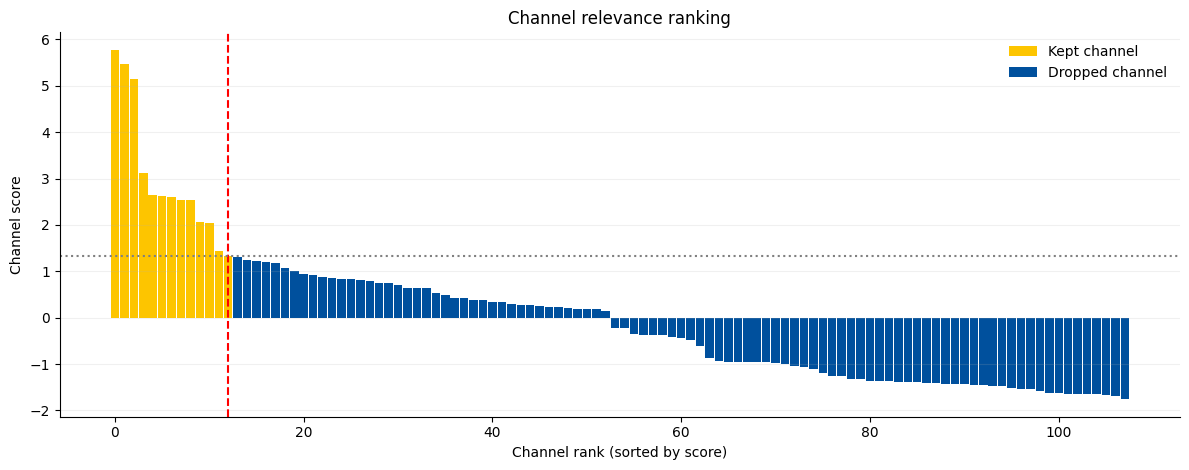


Top ranked channels:
 channel_id channel_name    score  selected
          9          Ch9 5.774454      True
         11         Ch11 5.470234      True
         14         Ch14 5.150614      True
         36         Ch36 3.121510      True
         89         Ch89 2.642229      True
         88         Ch88 2.624147      True
         85         Ch85 2.604017      True
         82         Ch82 2.537686      True
         87         Ch87 2.529879      True
         84         Ch84 2.054333      True
         45         Ch45 2.037079      True
         81         Ch81 1.427643      True
         30         Ch30 1.321083      True
        102        Ch102 1.307035     False
         83         Ch83 1.242215     False


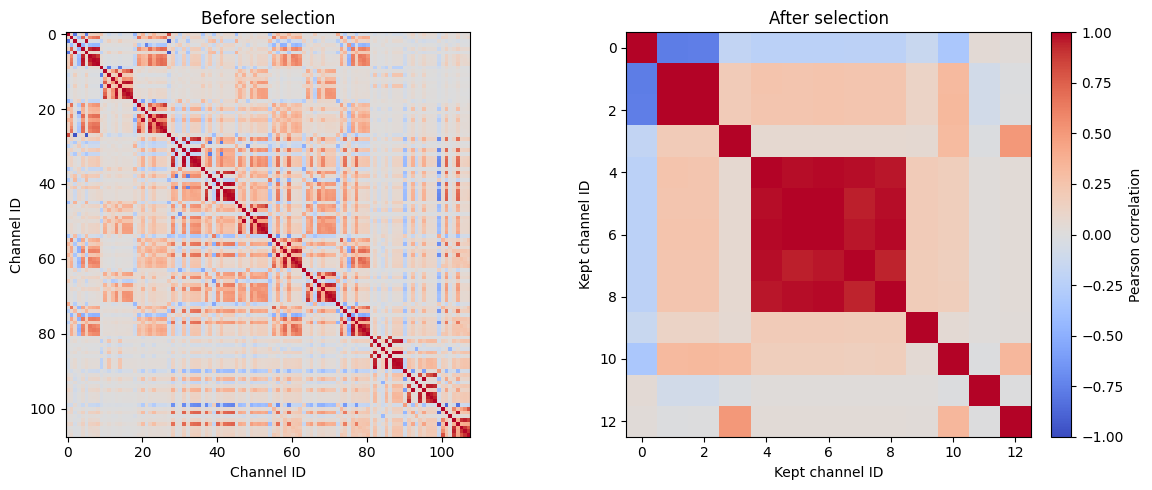

Mean |corr| before: 0.16471592708464305
Mean |corr| after : 0.27790767282146184


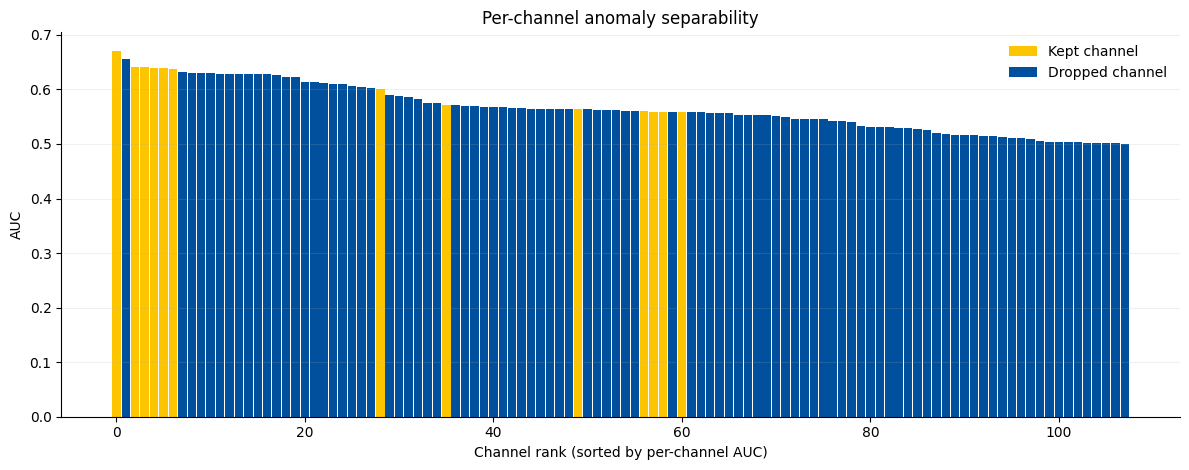


Top channels by per-channel AUC:
 channel_id channel_name      auc  selected
         84         Ch84 0.671100      True
         54         Ch54 0.655258     False
         88         Ch88 0.640713      True
         85         Ch85 0.640228      True
         89         Ch89 0.639964      True
         82         Ch82 0.639506      True
         87         Ch87 0.637747      True
         24         Ch24 0.632058     False
         25         Ch25 0.630216     False
         26         Ch26 0.630060     False
         19         Ch19 0.629520     False
         39         Ch39 0.628630     False
         77         Ch77 0.628319     False
         90         Ch90 0.628289     False
         80         Ch80 0.627943     False


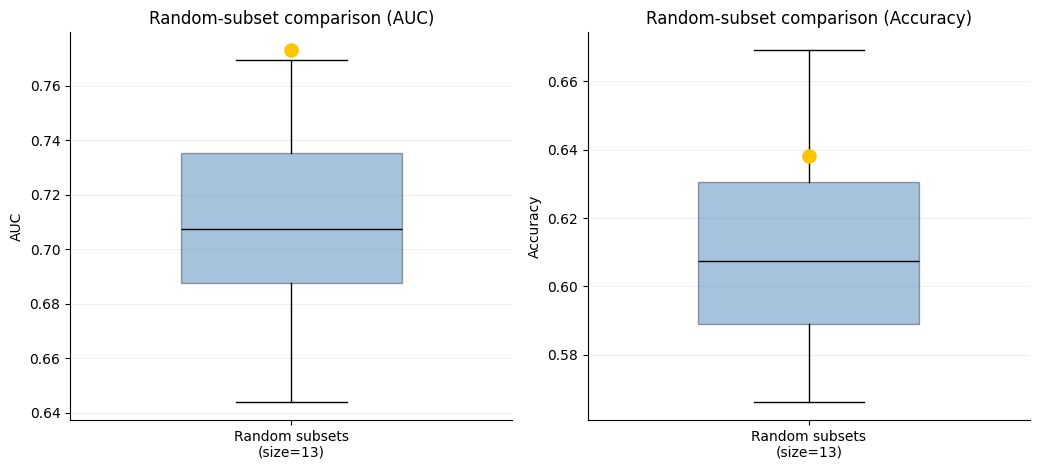

Selected subset metrics:
{'accuracy': 0.6382739212007504, 'precision': 0.941304347826087, 'recall': 0.18551842330762638, 'f1': 0.30994989262705797, 'auc': np.float64(0.773164848189474), 'threshold': 2.2853314876556396}
Random subset AUC mean ± std: 0.710268149115511 ± 0.03260754918472218
Random subset ACC mean ± std: 0.6114446529080675 ± 0.027895401454262066

Channel selection ablation:
                  variant  num_channels  accuracy  precision   recall       f1      auc  runtime_sec
Without channel selection           108  0.659287   0.924590 0.241645 0.383152 0.752630    67.408324
   With channel selection            13  0.638274   0.941304 0.185518 0.309950 0.773165     8.075940


In [ ]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import NearestNeighbors

# ============================================================
# KEEP FULL-CHANNEL COPIES BEFORE SELECTION
# ============================================================
X_train_full = X_train.copy()
X_test_full = X_test.copy()

# ============================================================
# RUN CHANNEL SELECTION
# ============================================================
dropped_channels, kept_channels, scores, details, threshold, elbow_index = \
    select_channels_unsupervised_snr_spearman_elbow(
        X_train_full,
        beta=1.0
    )

print("Total channels:", X_train_full.shape[1])
print("Elbow index:", elbow_index)
print("Threshold:", threshold)
print("Kept channels:", kept_channels)
print("Num kept:", len(kept_channels))
print("Dropped channels:", dropped_channels)
print("Num dropped:", len(dropped_channels))

# selected-channel data
X_train_sel = X_train_full[:, kept_channels, :]
X_test_sel  = X_test_full[:, kept_channels, :]

# ============================================================
# HELPER: channel names
# If you have real feature names, put them here.
# Otherwise generic labels are used.
# ============================================================
def make_channel_names(C):
    return [f"Ch{c}" for c in range(C)]

channel_names_full = make_channel_names(X_train_full.shape[1])

# ============================================================
# FIGURE 1: CHANNEL SCORE RANKING
# ============================================================
def plot_channel_score_ranking(scores, kept_channels, threshold=None, elbow_index=None, channel_names=None):
    scores = np.asarray(scores, dtype=float)
    kept_set = set(kept_channels)

    order = np.argsort(scores)[::-1]
    sorted_scores = scores[order]
    colors = ["#fdc500" if c in kept_set else "#00509d" for c in order]

    plt.figure(figsize=(12, 4.8))
    plt.bar(np.arange(len(order)), sorted_scores, color=colors, width=0.9)

    if elbow_index is not None:
        plt.axvline(elbow_index, color="red", linestyle="--", linewidth=1.5, label="Elbow index")

    if threshold is not None:
        plt.axhline(threshold, color="gray", linestyle=":", linewidth=1.5, label="Threshold")

    plt.xlabel("Channel rank (sorted by score)")
    plt.ylabel("Channel score")
    plt.title("Channel relevance ranking")
    plt.grid(True, axis="y", alpha=0.18)

    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor="#fdc500", label="Kept channel"),
        Patch(facecolor="#00509d", label="Dropped channel"),
    ]
    if elbow_index is not None or threshold is not None:
        plt.legend(handles=handles, frameon=False, loc="upper right")
    else:
        plt.legend(handles=handles, frameon=False)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    # optional printed ranking
    if channel_names is not None:
        ranked_df = pd.DataFrame({
            "channel_id": order,
            "channel_name": [channel_names[i] for i in order],
            "score": sorted_scores,
            "selected": [i in kept_set for i in order]
        })
        print("\nTop ranked channels:")
        print(ranked_df.head(15).to_string(index=False))

# ============================================================
# HELPER: flatten channels across samples/time
# (C, N*T) representation for channel correlation
# ============================================================
def flatten_channels(X):
    # X: (N, C, T) -> (C, N*T)
    return X.transpose(1, 0, 2).reshape(X.shape[1], -1)

# ============================================================
# FIGURE 2: CORRELATION HEATMAP BEFORE / AFTER
# ============================================================
def plot_channel_correlation_heatmaps(X_train_full, kept_channels):
    Xflat_full = flatten_channels(X_train_full)
    corr_before = np.corrcoef(Xflat_full)
    corr_before = np.nan_to_num(corr_before, nan=0.0)

    Xflat_kept = flatten_channels(X_train_full[:, kept_channels, :])
    corr_after = np.corrcoef(Xflat_kept)
    corr_after = np.nan_to_num(corr_after, nan=0.0)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im0 = axes[0].imshow(corr_before, cmap="coolwarm", vmin=-1, vmax=1)
    axes[0].set_title("Before selection")
    axes[0].set_xlabel("Channel ID")
    axes[0].set_ylabel("Channel ID")

    im1 = axes[1].imshow(corr_after, cmap="coolwarm", vmin=-1, vmax=1)
    axes[1].set_title("After selection")
    axes[1].set_xlabel("Kept channel ID")
    axes[1].set_ylabel("Kept channel ID")

    cbar = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label("Pearson correlation")

    plt.tight_layout()
    plt.show()

    abs_before = np.abs(corr_before[np.triu_indices_from(corr_before, k=1)])
    abs_after = np.abs(corr_after[np.triu_indices_from(corr_after, k=1)])

    print("Mean |corr| before:", abs_before.mean())
    print("Mean |corr| after :", abs_after.mean())

# ============================================================
# FIGURE 3: CHANNEL SEPARABILITY PLOT
# option A: per-channel AUC
# ============================================================
def plot_channel_separability_auc(X_test_full, y_test, kept_channels, channel_names=None):
    Xflat = flatten_channels(X_test_full)  # (C, N*T) not suitable for y_test window labels
    # For per-window channel summary, use mean absolute channel activation per sample
    # shape -> (N, C)
    Xsummary = np.mean(np.abs(X_test_full), axis=2)

    aucs = np.zeros(Xsummary.shape[1], dtype=float)
    for c in range(Xsummary.shape[1]):
        s = Xsummary[:, c]
        if np.allclose(s, s[0]):
            aucs[c] = 0.5
        else:
            aucs[c] = roc_auc_score(y_test, s)
        if aucs[c] < 0.5:
            aucs[c] = 1.0 - aucs[c]

    kept_set = set(kept_channels)
    order = np.argsort(aucs)[::-1]
    sorted_aucs = aucs[order]
    colors = ["#fdc500" if c in kept_set else "#00509d" for c in order]

    plt.figure(figsize=(12, 4.8))
    plt.bar(np.arange(len(order)), sorted_aucs, color=colors, width=0.9)
    plt.xlabel("Channel rank (sorted by per-channel AUC)")
    plt.ylabel("AUC")
    plt.title("Per-channel anomaly separability")
    plt.grid(True, axis="y", alpha=0.18)

    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor="#fdc500", label="Kept channel"),
        Patch(facecolor="#00509d", label="Dropped channel"),
    ]
    plt.legend(handles=handles, frameon=False)

    ax = plt.gca()
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    if channel_names is not None:
        ranked_df = pd.DataFrame({
            "channel_id": order,
            "channel_name": [channel_names[i] for i in order],
            "auc": sorted_aucs,
            "selected": [i in kept_set for i in order]
        })
        print("\nTop channels by per-channel AUC:")
        print(ranked_df.head(15).to_string(index=False))

    return aucs

# ============================================================
# HELPER: one-class KNN evaluation
# Uses same logic as your current experiment, but simpler
# ============================================================
def evaluate_knn_oneclass(X_train_use, X_test_use, y_test, k_neighbors=5, quantile=0.999):
    Ntr, C, T = X_train_use.shape
    Nte = X_test_use.shape[0]

    Ztr = X_train_use.reshape(Ntr, -1).astype(np.float32)
    Zte = X_test_use.reshape(Nte, -1).astype(np.float32)

    k = min(int(k_neighbors), max(2, Ztr.shape[0]))
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(Ztr)

    d_train, _ = nn.kneighbors(Ztr)
    d_test, _ = nn.kneighbors(Zte)

    train_scores = d_train.mean(axis=1).astype(np.float32)
    test_scores = d_test.mean(axis=1).astype(np.float32)

    threshold = np.quantile(train_scores, quantile)
    y_pred = (test_scores > threshold).astype(np.int64)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label=1, zero_division=0),
        "recall": recall_score(y_test, y_pred, pos_label=1, zero_division=0),
        "f1": f1_score(y_test, y_pred, pos_label=1, zero_division=0),
        "auc": roc_auc_score(y_test, test_scores),
        "threshold": float(threshold),
    }

# ============================================================
# FIGURE 4: RANDOM-SUBSET BOXPLOT
# Compare your selected subset against many random subsets
# of the same size
# ============================================================
def plot_random_subset_comparison(
    X_train_full,
    X_test_full,
    X_train_sel,
    X_test_sel,
    y_test,
    n_random=30,
    random_state=0,
    k_neighbors=5,
    quantile=0.999
):
    rng = np.random.default_rng(random_state)
    C_full = X_train_full.shape[1]
    m = X_train_sel.shape[1]

    random_aucs = []
    random_accs = []

    for _ in range(n_random):
        subset = rng.choice(C_full, size=m, replace=False)
        subset.sort()

        metrics = evaluate_knn_oneclass(
            X_train_full[:, subset, :],
            X_test_full[:, subset, :],
            y_test,
            k_neighbors=k_neighbors,
            quantile=quantile
        )
        random_aucs.append(metrics["auc"])
        random_accs.append(metrics["accuracy"])

    selected_metrics = evaluate_knn_oneclass(
        X_train_sel,
        X_test_sel,
        y_test,
        k_neighbors=k_neighbors,
        quantile=quantile
    )

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8))

    # AUC
    axes[0].boxplot(random_aucs, widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor="#00509d", alpha=0.35),
                    medianprops=dict(color="black"))
    axes[0].scatter(1, selected_metrics["auc"], s=90, color="#fdc500", zorder=5)
    axes[0].set_xticks([1])
    axes[0].set_xticklabels([f"Random subsets\n(size={m})"])
    axes[0].set_ylabel("AUC")
    axes[0].set_title("Random-subset comparison (AUC)")
    axes[0].grid(True, axis="y", alpha=0.18)

    # Accuracy
    axes[1].boxplot(random_accs, widths=0.5, patch_artist=True,
                    boxprops=dict(facecolor="#00509d", alpha=0.35),
                    medianprops=dict(color="black"))
    axes[1].scatter(1, selected_metrics["accuracy"], s=90, color="#fdc500", zorder=5)
    axes[1].set_xticks([1])
    axes[1].set_xticklabels([f"Random subsets\n(size={m})"])
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Random-subset comparison (Accuracy)")
    axes[1].grid(True, axis="y", alpha=0.18)

    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

    print("Selected subset metrics:")
    print(selected_metrics)
    print("Random subset AUC mean ± std:", np.mean(random_aucs), "±", np.std(random_aucs, ddof=1))
    print("Random subset ACC mean ± std:", np.mean(random_accs), "±", np.std(random_accs, ddof=1))

    return {
        "selected_metrics": selected_metrics,
        "random_aucs": random_aucs,
        "random_accs": random_accs,
    }

# ============================================================
# FIGURE 5: FINAL ABLATION TABLE
# with / without channel selection
# ============================================================
def build_channel_ablation_table(
    X_train_full,
    X_test_full,
    X_train_sel,
    X_test_sel,
    y_test,
    k_neighbors=5,
    quantile=0.999
):
    rows = []

    t0 = time.perf_counter()
    metrics_full = evaluate_knn_oneclass(
        X_train_full, X_test_full, y_test,
        k_neighbors=k_neighbors, quantile=quantile
    )
    rt_full = time.perf_counter() - t0

    rows.append({
        "variant": "Without channel selection",
        "num_channels": X_train_full.shape[1],
        "accuracy": metrics_full["accuracy"],
        "precision": metrics_full["precision"],
        "recall": metrics_full["recall"],
        "f1": metrics_full["f1"],
        "auc": metrics_full["auc"],
        "runtime_sec": rt_full,
    })

    t0 = time.perf_counter()
    metrics_sel = evaluate_knn_oneclass(
        X_train_sel, X_test_sel, y_test,
        k_neighbors=k_neighbors, quantile=quantile
    )
    rt_sel = time.perf_counter() - t0

    rows.append({
        "variant": "With channel selection",
        "num_channels": X_train_sel.shape[1],
        "accuracy": metrics_sel["accuracy"],
        "precision": metrics_sel["precision"],
        "recall": metrics_sel["recall"],
        "f1": metrics_sel["f1"],
        "auc": metrics_sel["auc"],
        "runtime_sec": rt_sel,
    })

    ablation_df = pd.DataFrame(rows)
    print("\nChannel selection ablation:")
    print(ablation_df.to_string(index=False))
    return ablation_df

# ============================================================
# RUN ALL PLOTS / TABLES
# ============================================================
plot_channel_score_ranking(
    scores=scores,
    kept_channels=kept_channels,
    threshold=threshold,
    elbow_index=elbow_index,
    channel_names=channel_names_full
)

plot_channel_correlation_heatmaps(
    X_train_full=X_train_full,
    kept_channels=kept_channels
)

channel_aucs = plot_channel_separability_auc(
    X_test_full=X_test_full,
    y_test=y_test,
    kept_channels=kept_channels,
    channel_names=channel_names_full
)

random_subset_results = plot_random_subset_comparison(
    X_train_full=X_train_full,
    X_test_full=X_test_full,
    X_train_sel=X_train_sel,
    X_test_sel=X_test_sel,
    y_test=y_test,
    n_random=30,
    random_state=0,
    k_neighbors=5,
    quantile=0.999
)

channel_ablation_df = build_channel_ablation_table(
    X_train_full=X_train_full,
    X_test_full=X_test_full,
    X_train_sel=X_train_sel,
    X_test_sel=X_test_sel,
    y_test=y_test,
    k_neighbors=5,
    quantile=0.999
)


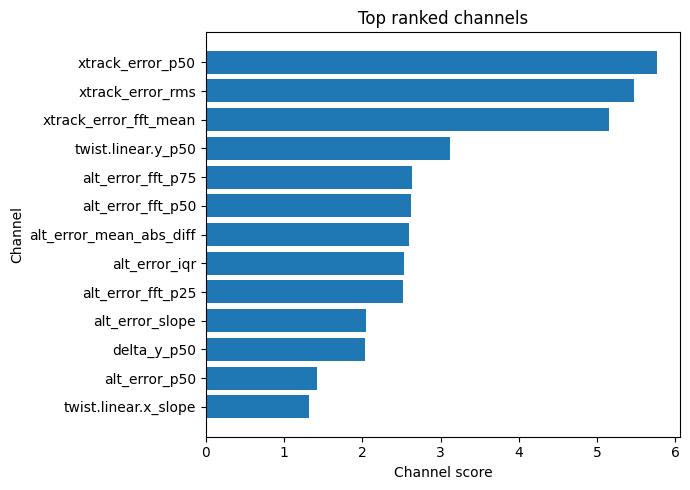

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

channels = [
    "xtrack_error_p50",
    "xtrack_error_rms",
    "xtrack_error_fft_mean",
    "twist.linear.y_p50",
    "alt_error_fft_p75",
    "alt_error_fft_p50",
    "alt_error_mean_abs_diff",
    "alt_error_iqr",
    "alt_error_fft_p25",
    "alt_error_slope",
    "delta_y_p50",
    "alt_error_p50",
    "twist.linear.x_slope",
]

scores = [
    5.77, 5.47, 5.15, 3.12, 2.64, 2.62, 2.60,
    2.53, 2.52, 2.05, 2.03, 1.42, 1.32
]

# reverse so highest score appears at top
channels = channels[::-1]
scores = scores[::-1]

plt.figure(figsize=(7,5))

plt.barh(channels, scores)

plt.xlabel("Channel score")
plt.ylabel("Channel")
plt.title("Top ranked channels")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

CSV_PATH = "/content/drive/MyDrive/Dr.Noura/RocketBoost/FaultDetection_ALFA-Dataset-master/failures/laplacian_selected_multiclass/laplacian_selected_feature_table_multiclass.csv"

# channel ids you provided
channel_ids = [9,11,14,36,89,88,85,82,87,84,45,81,30]

# load dataframe
df = pd.read_csv(CSV_PATH)

# same metadata removal used in your pipeline
meta_cols = {"label", "source_file", "source_folder", "start_row", "end_row"}
feature_cols = [c for c in df.columns if c not in meta_cols]

# print mapping
for cid in range(108):
    print(cid, feature_cols[cid])


0 field.orientation.z_p50
1 field.orientation.z_iqr
2 field.orientation.z_rms
3 field.orientation.z_slope
4 field.orientation.z_mean_abs_diff
5 field.orientation.z_fft_mean
6 field.orientation.z_fft_p25
7 field.orientation.z_fft_p50
8 field.orientation.z_fft_p75
9 field.xtrack_error_p50
10 field.xtrack_error_iqr
11 field.xtrack_error_rms
12 field.xtrack_error_slope
13 field.xtrack_error_mean_abs_diff
14 field.xtrack_error_fft_mean
15 field.xtrack_error_fft_p25
16 field.xtrack_error_fft_p50
17 field.xtrack_error_fft_p75
18 delta_yaw_p50
19 delta_yaw_iqr
20 delta_yaw_rms
21 delta_yaw_slope
22 delta_yaw_mean_abs_diff
23 delta_yaw_fft_mean
24 delta_yaw_fft_p25
25 delta_yaw_fft_p50
26 delta_yaw_fft_p75
27 field.twist.linear.x_p50
28 field.twist.linear.x_iqr
29 field.twist.linear.x_rms
30 field.twist.linear.x_slope
31 field.twist.linear.x_mean_abs_diff
32 field.twist.linear.x_fft_mean
33 field.twist.linear.x_fft_p25
34 field.twist.linear.x_fft_p50
35 field.twist.linear.x_fft_p75
36 field.twi

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

# ============================================================
# SETTINGS
# ============================================================
NUM_FEATURES = 1000
MAX_DILATIONS = 32
TAU = 0.7
THRESHOLD_QUANTILE = 0.999
K_NEIGHBORS = 5
N_RUNS = 15

# optional save paths
SAVE_RUNS_CSV = "minirocket_knn_15runs_results.csv"
SAVE_CM_NPY = "minirocket_knn_median_confusion_matrix.npy"
SAVE_CM_CSV = "minirocket_knn_median_confusion_matrix.csv"

# ============================================================
# RUNS
# ============================================================
run_rows = []
cms = []
y_preds = []

for run_idx in range(N_RUNS):
    print(f"\n================ RUN {run_idx + 1}/{N_RUNS} ================")
    t0 = time.perf_counter()

    # --------------------------------------------------------
    # FIT MINIROCKET ON NORMAL TRAIN ONLY
    # --------------------------------------------------------
    params = fit(
        X_train.astype(np.float32),
        num_features=NUM_FEATURES,
        max_dilations_per_kernel=MAX_DILATIONS
    )

    _, _, dilations, num_features_per_dilation, _ = params

    # --------------------------------------------------------
    # TRANSFORM TRAIN / TEST
    # --------------------------------------------------------
    Ztr_full = transform(X_train.astype(np.float32), params).astype(np.float32)
    Zte_full = transform(X_test.astype(np.float32),  params).astype(np.float32)

    # --------------------------------------------------------
    # KERNEL SELECTION USING VARIANCE
    # --------------------------------------------------------
    S = kernel_signatures(Ztr_full, num_features_per_dilation)

    kept_kernels = prune_correlated_kernels(
        S,
        y=None,
        tau=TAU,
        method="variance"
    )

    kept_cols = kept_kernel_feature_cols(
        kept_kernels,
        num_features_per_dilation
    )

    Ztr = Ztr_full[:, kept_cols]
    Zte = Zte_full[:, kept_cols]

    # --------------------------------------------------------
    # KNN ANOMALY SCORING
    # --------------------------------------------------------
    k = min(int(K_NEIGHBORS), max(2, Ztr.shape[0]))
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(Ztr)

    d_train, _ = nn.kneighbors(Ztr)
    d_test, _ = nn.kneighbors(Zte)

    train_scores = d_train.mean(axis=1).astype(np.float32)
    test_scores = d_test.mean(axis=1).astype(np.float32)

    # --------------------------------------------------------
    # THRESHOLD FROM TRAIN ONLY
    # --------------------------------------------------------
    threshold = np.quantile(train_scores, THRESHOLD_QUANTILE)
    y_pred = (test_scores > threshold).astype(np.int64)

    # --------------------------------------------------------
    # EVALUATION
    # --------------------------------------------------------
# --------------------------------------------------------
# EVALUATION
# --------------------------------------------------------
    acc = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    # AUC using anomaly scores
    auc = roc_auc_score(y_test, test_scores)

    cm = confusion_matrix(y_test, y_pred)

    D_full = Ztr_full.shape[1]
    D_kept = Ztr.shape[1]
    reduction_ratio = 100.0 * (1.0 - D_kept / D_full)

    runtime_sec = time.perf_counter() - t0

    print("Threshold:", threshold)
    print("Accuracy:", acc)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("AUC:", auc)
    print("Runtime (s):", runtime_sec)
    print("Reduction (%):", reduction_ratio)
    print("Kept kernels:", len(kept_kernels))
    print("Confusion matrix:\n", cm)

    run_rows.append({
        "run": run_idx + 1,
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": float(auc),
        "runtime_sec": float(runtime_sec),
        "reduction_ratio_pct": float(reduction_ratio),
        "threshold": float(threshold),
        "num_kept_kernels": int(len(kept_kernels)),
        "full_features": int(D_full),
        "kept_features": int(D_kept),
    })
    cms.append(cm)
    y_preds.append(y_pred.copy())

# ============================================================
# RESULTS TABLE
# ============================================================
results_df = pd.DataFrame(run_rows)

print("\n================ PER-RUN RESULTS ================")
print(results_df)

# ============================================================
# SUMMARY STATISTICS
# ============================================================
summary = {
    "accuracy_mean": results_df["accuracy"].mean(),
    "accuracy_std": results_df["accuracy"].std(ddof=1),

    "precision_mean": results_df["precision"].mean(),
    "precision_std": results_df["precision"].std(ddof=1),

    "recall_mean": results_df["recall"].mean(),
    "recall_std": results_df["recall"].std(ddof=1),

    "f1_mean": results_df["f1"].mean(),
    "f1_std": results_df["f1"].std(ddof=1),

    "auc_mean": results_df["auc"].mean(),
    "auc_std": results_df["auc"].std(ddof=1),

    "runtime_mean_sec": results_df["runtime_sec"].mean(),
    "runtime_std_sec": results_df["runtime_sec"].std(ddof=1),

    "reduction_mean_pct": results_df["reduction_ratio_pct"].mean(),
    "reduction_std_pct": results_df["reduction_ratio_pct"].std(ddof=1),
}

print("\n================ SUMMARY ================")
for k, v in summary.items():
    print(f"{k}: {v:.6f}")

# ============================================================
# MEDIAN RUN SELECTION
# median run based on accuracy
# ============================================================
median_auc = results_df["auc"].median()
median_run_pos = (results_df["auc"] - median_auc).abs().idxmin()

median_run_number = int(results_df.loc[median_run_pos, "run"])
median_cm = cms[median_run_pos]
median_y_pred = y_preds[median_run_pos]

print("\n================ MEDIAN RUN ================")
print("Median target AUC:", median_auc)
print("Chosen run:", median_run_number)
print("Chosen run accuracy:", results_df.loc[median_run_pos, "accuracy"])
print("Chosen run runtime (s):", results_df.loc[median_run_pos, "runtime_sec"])
print("Chosen run reduction (%):", results_df.loc[median_run_pos, "reduction_ratio_pct"])
print("Median run confusion matrix:\n", median_cm)

print("\nMedian run classification report:")
print(classification_report(y_test, median_y_pred, digits=4))

# ============================================================
# SAVE
# ============================================================
results_df.to_csv(SAVE_RUNS_CSV, index=False)
np.save(SAVE_CM_NPY, median_cm)

pd.DataFrame(
    median_cm,
    index=["true_0", "true_1"],
    columns=["pred_0", "pred_1"]
).to_csv(SAVE_CM_CSV)

print("\nSaved:")
print(" -", SAVE_RUNS_CSV)
print(" -", SAVE_CM_NPY)
print(" -", SAVE_CM_CSV)


================ RUN 1/15 ================
Threshold: 1.7421132
Accuracy: 0.9729376633072042
Precision: 0.9502024291497976
Recall: 0.990713381173491
F1: 0.9700351312254598
AUC: 0.9974020402090625
Runtime (s): 25.52907077999771
Reduction (%): 20.238095238095234
Kept kernels: 67
Confusion matrix:
 [[2866  123]
 [  22 2347]]

================ RUN 2/15 ================
Threshold: 1.8098814
Accuracy: 0.9766703994027622
Precision: 0.9564686737184703
Recall: 0.9924018573237653
F1: 0.9741039983426559
AUC: 0.9981701584577529
Runtime (s): 27.278569792997587
Reduction (%): 20.238095238095234
Kept kernels: 67
Confusion matrix:
 [[2882  107]
 [  18 2351]]

================ RUN 3/15 ================
Threshold: 1.7101051
Accuracy: 0.9738708473310936
Precision: 0.9495764421137556
Recall: 0.9936682144364711
F1: 0.9711221122112211
AUC: 0.9984160297339012
Runtime (s): 24.89221344100224
Reduction (%): 23.809523809523814
Kept kernels: 64
Confusion matrix:
 [[2864  125]
 [  15 2354]]

================ RUN 

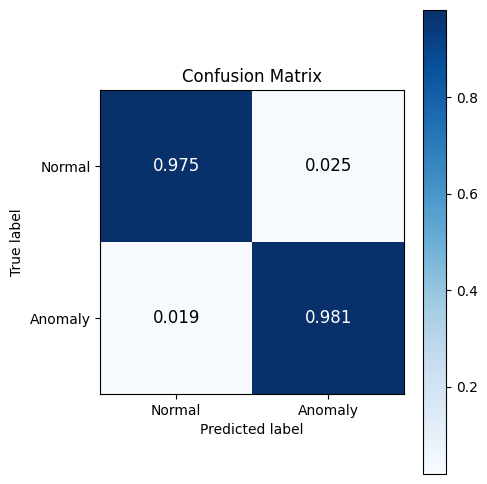

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, class_names=("Normal", "Anomaly"), normalize=False):

    if normalize:
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(5,5))

    im = ax.imshow(cm, cmap="Blues")

    # ticks
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    # annotate cells
    thresh = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]

            if normalize:
                text = f"{value:.3f}"
            else:
                text = f"{int(value)}"

            ax.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                color="white" if value > thresh else "black",
                fontsize=12
            )

    fig.colorbar(im, ax=ax)

    ax.set_title("Confusion Matrix")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(median_cm, normalize=True)

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score

# ============================================================
# BASELINE SETTINGS
# ============================================================
BASE_NUM_FEATURES = 1000
BASE_MAX_DILATIONS = 32
BASE_TAU = 0.7
BASE_THRESHOLD_QUANTILE = 0.999
BASE_K_NEIGHBORS = 5

# ============================================================
# CANDIDATES
# ============================================================
NUM_FEATURES_CANDIDATES = [500, 1000, 2000, 5000]
MAX_DILATIONS_CANDIDATES = [32]
TAU_CANDIDATES = [0.5, 0.6, 0.7, 0.8]
THRESHOLD_QUANTILE_CANDIDATES = [0.95, 0.99, 0.995, 0.999]
K_NEIGHBORS_CANDIDATES = [1, 3, 5, 7, 9, 15]
N_RUNS = 5

# ============================================================
# SINGLE EXPERIMENT
# ============================================================
def run_single_experiment(
    X_train,
    X_test,
    y_test,
    num_features,
    max_dilations,
    tau,
    threshold_quantile,
    k_neighbors,
):
    t0 = time.perf_counter()

    # -----------------------------
    # Fit MiniRocket
    # -----------------------------
    params = fit(
        X_train.astype(np.float32),
        num_features=num_features,
        max_dilations_per_kernel=max_dilations
    )

    _, _, dilations, num_features_per_dilation, _ = params

    # -----------------------------
    # Transform train / test
    # -----------------------------
    Ztr_full = transform(X_train.astype(np.float32), params).astype(np.float32)
    Zte_full = transform(X_test.astype(np.float32),  params).astype(np.float32)

    # -----------------------------
    # Kernel selection using variance
    # -----------------------------
    S = kernel_signatures(Ztr_full, num_features_per_dilation)

    kept_kernels = prune_correlated_kernels(
        S,
        y=None,
        tau=tau,
        method="variance"
    )

    kept_cols = kept_kernel_feature_cols(
        kept_kernels,
        num_features_per_dilation
    )

    Ztr = Ztr_full[:, kept_cols]
    Zte = Zte_full[:, kept_cols]

    # -----------------------------
    # kNN anomaly scoring
    # -----------------------------
    k = min(int(k_neighbors), max(2, Ztr.shape[0]))
    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(Ztr)

    d_train, _ = nn.kneighbors(Ztr)
    d_test, _ = nn.kneighbors(Zte)

    train_scores = d_train.mean(axis=1).astype(np.float32)
    test_scores = d_test.mean(axis=1).astype(np.float32)

    # -----------------------------
    # Threshold from train only
    # -----------------------------
    threshold = np.quantile(train_scores, threshold_quantile)
    y_pred = (test_scores > threshold).astype(np.int64)

    # -----------------------------
    # Evaluation
    # -----------------------------
    acc = accuracy_score(y_test, y_pred)

    D_full = Ztr_full.shape[1]
    D_kept = Ztr.shape[1]
    feature_reduction_pct = 100.0 * (1.0 - D_kept / D_full)

    runtime_sec = time.perf_counter() - t0

    return {
        "accuracy": float(acc),
        "runtime_sec": float(runtime_sec),
        "threshold": float(threshold),
        "num_kept_kernels": int(len(kept_kernels)),
        "full_features": int(D_full),
        "kept_features": int(D_kept),
        "feature_reduction_pct": float(feature_reduction_pct),
    }

# ============================================================
# PARAMETER SWEEP HELPER
# ============================================================
def run_parameter_sweep(
    X_train,
    X_test,
    y_test,
    parameter_name,
    candidate_values,
    n_runs=5,
):
    rows = []

    for value in candidate_values:
        print(f"\n=== Sweeping {parameter_name} = {value} ===")

        run_metrics = []

        for run_idx in range(n_runs):
            print(f"  Run {run_idx + 1}/{n_runs}")

            # fixed baseline
            cfg = {
                "num_features": BASE_NUM_FEATURES,
                "max_dilations": BASE_MAX_DILATIONS,
                "tau": BASE_TAU,
                "threshold_quantile": BASE_THRESHOLD_QUANTILE,
                "k_neighbors": BASE_K_NEIGHBORS,
            }

            # replace the current parameter
            cfg[parameter_name] = value

            out = run_single_experiment(
                X_train=X_train,
                X_test=X_test,
                y_test=y_test,
                num_features=cfg["num_features"],
                max_dilations=cfg["max_dilations"],
                tau=cfg["tau"],
                threshold_quantile=cfg["threshold_quantile"],
                k_neighbors=cfg["k_neighbors"],
            )

            out["run"] = run_idx
            out["swept_parameter"] = parameter_name
            out["parameter_value"] = value
            out["num_features"] = cfg["num_features"]
            out["max_dilations"] = cfg["max_dilations"]
            out["tau"] = cfg["tau"]
            out["threshold_quantile"] = cfg["threshold_quantile"]
            out["k_neighbors"] = cfg["k_neighbors"]

            run_metrics.append(out)

        # store per-run rows
        rows.extend(run_metrics)

    return pd.DataFrame(rows)

# ============================================================
# RUN ALL SWEEPS
# ============================================================
all_results = []

all_results.append(
    run_parameter_sweep(
        X_train=X_train,
        X_test=X_test,
        y_test=y_test,
        parameter_name="num_features",
        candidate_values=NUM_FEATURES_CANDIDATES,
        n_runs=N_RUNS,
    )
)

all_results.append(
    run_parameter_sweep(
        X_train=X_train,
        X_test=X_test,
        y_test=y_test,
        parameter_name="max_dilations",
        candidate_values=MAX_DILATIONS_CANDIDATES,
        n_runs=N_RUNS,
    )
)

all_results.append(
    run_parameter_sweep(
        X_train=X_train,
        X_test=X_test,
        y_test=y_test,
        parameter_name="tau",
        candidate_values=TAU_CANDIDATES,
        n_runs=N_RUNS,
    )
)

all_results.append(
    run_parameter_sweep(
        X_train=X_train,
        X_test=X_test,
        y_test=y_test,
        parameter_name="threshold_quantile",
        candidate_values=THRESHOLD_QUANTILE_CANDIDATES,
        n_runs=N_RUNS,
    )
)

all_results.append(
    run_parameter_sweep(
        X_train=X_train,
        X_test=X_test,
        y_test=y_test,
        parameter_name="k_neighbors",
        candidate_values=K_NEIGHBORS_CANDIDATES,
        n_runs=N_RUNS,
    )
)

results_df = pd.concat(all_results, ignore_index=True)

print("\n================ RAW RESULTS ================")
print(results_df.head())

# ============================================================
# AGGREGATE FOR PLOTTING
# ============================================================
plot_df = (
    results_df
    .groupby(["swept_parameter", "parameter_value"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        runtime_mean=("runtime_sec", "mean"),
        runtime_std=("runtime_sec", "std"),
        threshold_mean=("threshold", "mean"),
        threshold_std=("threshold", "std"),
        kept_kernels_mean=("num_kept_kernels", "mean"),
        kept_kernels_std=("num_kept_kernels", "std"),
        kept_features_mean=("kept_features", "mean"),
        kept_features_std=("kept_features", "std"),
        reduction_mean=("feature_reduction_pct", "mean"),
        reduction_std=("feature_reduction_pct", "std"),
    )
)

print("\n================ AGGREGATED RESULTS ================")
print(plot_df)

# ============================================================
# OPTIONAL SAVE
# ============================================================
results_df.to_csv("parameter_sweep_runs.csv", index=False)
plot_df.to_csv("parameter_sweep_summary.csv", index=False)

print("\nSaved:")
print(" - parameter_sweep_runs.csv")
print(" - parameter_sweep_summary.csv")

In [ ]:
import time
import numpy as np
from sklearn.metrics import accuracy_score
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier



def run_distance_baseline(distance="euclidean", n_neighbors=1):
    t0 = time.time()

    # X_train / X_test are assumed to already be in aeon format: (N, C, T)
    # If your current arrays are (N, T, C), transpose them before this block.

    clf = KNeighborsTimeSeriesClassifier(
        n_neighbors=n_neighbors,
        distance=distance
    )
    print(X_train.shape)
    clf.fit(X_train.astype(np.float32), y_train)
    y_pred = clf.predict(X_test.astype(np.float32))

    acc = accuracy_score(y_test, y_pred)
    elapsed = time.time() - t0

    return {
        "distance": distance,
        "n_neighbors": n_neighbors,
        "accuracy": acc,
        "runtime_sec": elapsed,
    }

# ============================================================
# RUN BASELINES
# ============================================================
res_euclidean = run_distance_baseline(distance="euclidean", n_neighbors=3)
res_dtw = run_distance_baseline(distance="dtw", n_neighbors=3)

print("=== EUCLIDEAN 1-NN ===")
for k, v in res_euclidean.items():
    print(f"{k}: {v}")

print("\n=== DTW 1-NN ===")
for k, v in res_dtw.items():
    print(f"{k}: {v}")

(11981, 108, 40)
(11981, 108, 40)
=== EUCLIDEAN 1-NN ===
distance: euclidean
n_neighbors: 3
accuracy: 0.5621013133208255
runtime_sec: 0.18364620208740234

=== DTW 1-NN ===
distance: dtw
n_neighbors: 3
accuracy: 0.5621013133208255
runtime_sec: 0.16317224502563477


# Visualization

In [ ]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(0)

# ------------------------------------------------------------
# Toy run-level results
# ------------------------------------------------------------
rows = []

# sweep 1: num_features
for val, acc_mu, rt_mu, red_mu in [
    (500,   0.88,  8.0, 55.0),
    (1000,  0.91, 11.5, 50.0),
    (2000,  0.935, 18.0, 46.0),
    (5000,  0.945, 34.0, 42.0),
    (10000, 0.947, 63.0, 40.0),
]:
    for run in range(5):
        rows.append({
            "swept_parameter": "num_features",
            "parameter_value": val,
            "run": run,
            "accuracy": acc_mu + rng.normal(0, 0.006),
            "runtime_sec": rt_mu + rng.normal(0, 0.8),
            "threshold": 0.995 + rng.normal(0, 0.0005),
            "num_kept_kernels": int(30 + rng.normal(0, 2)),
            "kept_features": int(800 + rng.normal(0, 30)),
            "feature_reduction_pct": red_mu + rng.normal(0, 1.0),
        })

# sweep 2: tau
for val, acc_mu, rt_mu, red_mu in [
    (0.5, 0.90, 19.0, 68.0),
    (0.6, 0.925, 20.0, 58.0),
    (0.7, 0.94, 21.0, 48.0),
    (0.8, 0.938, 22.0, 35.0),
    (0.9, 0.93, 23.0, 20.0),
]:
    for run in range(5):
        rows.append({
            "swept_parameter": "tau",
            "parameter_value": val,
            "run": run,
            "accuracy": acc_mu + rng.normal(0, 0.007),
            "runtime_sec": rt_mu + rng.normal(0, 0.6),
            "threshold": 0.995 + rng.normal(0, 0.0004),
            "num_kept_kernels": int(25 + 40 * val + rng.normal(0, 2)),
            "kept_features": int(700 + 250 * val + rng.normal(0, 20)),
            "feature_reduction_pct": red_mu + rng.normal(0, 1.2),
        })

# sweep 3: k_neighbors
for val, acc_mu, rt_mu, red_mu in [
    (1,  0.91, 18.0, 48.0),
    (3,  0.935, 18.5, 48.0),
    (5,  0.94, 19.0, 48.0),
    (7,  0.939, 19.5, 48.0),
    (9,  0.934, 20.0, 48.0),
    (15, 0.925, 21.5, 48.0),
]:
    for run in range(5):
        rows.append({
            "swept_parameter": "k_neighbors",
            "parameter_value": val,
            "run": run,
            "accuracy": acc_mu + rng.normal(0, 0.007),
            "runtime_sec": rt_mu + rng.normal(0, 0.5),
            "threshold": 0.995 + rng.normal(0, 0.0004),
            "num_kept_kernels": int(33 + rng.normal(0, 1)),
            "kept_features": int(920 + rng.normal(0, 20)),
            "feature_reduction_pct": red_mu + rng.normal(0, 0.5),
        })

results_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# Aggregated summary for plotting
# ------------------------------------------------------------
plot_df = (
    results_df
    .groupby(["swept_parameter", "parameter_value"], as_index=False)
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        runtime_mean=("runtime_sec", "mean"),
        runtime_std=("runtime_sec", "std"),
        threshold_mean=("threshold", "mean"),
        threshold_std=("threshold", "std"),
        kept_kernels_mean=("num_kept_kernels", "mean"),
        kept_kernels_std=("num_kept_kernels", "std"),
        kept_features_mean=("kept_features", "mean"),
        kept_features_std=("kept_features", "std"),
        reduction_mean=("feature_reduction_pct", "mean"),
        reduction_std=("feature_reduction_pct", "std"),
    )
)

print(results_df.head())
print()
print(plot_df.head())

  swept_parameter  parameter_value  run  accuracy  runtime_sec  threshold  \
0    num_features            500.0    0  0.880754     7.894316   0.995320   
1    num_features            500.0    1  0.887824     8.757665   0.994648   
2    num_features            500.0    2  0.866050     7.824967   0.994377   
3    num_features            500.0    3  0.882470     8.834011   0.994936   
4    num_features            500.0    4  0.885421     8.075210   0.994628   

   num_kept_kernels  kept_features  feature_reduction_pct  
0                30            783              55.361595  
1                27            781              55.041326  
2                28            783              54.683700  
3                32            780              55.351510  
4                28            786              55.220195  

  swept_parameter  parameter_value  accuracy_mean  accuracy_std  runtime_mean  \
0     k_neighbors              1.0       0.913253      0.006701     17.946236   
1     k_neighb

In [ ]:
import matplotlib.pyplot as plt

def plot_accuracy_vs_parameter(plot_df, swept_parameter):
    sub = plot_df[plot_df["swept_parameter"] == swept_parameter].copy()
    sub = sub.sort_values("parameter_value")

    x = sub["parameter_value"].values
    y = sub["accuracy_mean"].values
    yerr = sub["accuracy_std"].fillna(0).values

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
    plt.xlabel(swept_parameter)
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy vs {swept_parameter}")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_runtime_vs_parameter(plot_df, swept_parameter):
    sub = plot_df[plot_df["swept_parameter"] == swept_parameter].copy()
    sub = sub.sort_values("parameter_value")

    x = sub["parameter_value"].values
    y = sub["runtime_mean"].values
    yerr = sub["runtime_std"].fillna(0).values

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
    plt.xlabel(swept_parameter)
    plt.ylabel("Runtime (s)")
    plt.title(f"Runtime vs {swept_parameter}")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_accuracy_runtime_tradeoff(plot_df, swept_parameter):
    sub = plot_df[plot_df["swept_parameter"] == swept_parameter].copy()
    sub = sub.sort_values("parameter_value")

    x = sub["runtime_mean"].values
    y = sub["accuracy_mean"].values
    labels = sub["parameter_value"].values

    plt.figure(figsize=(6, 5))
    plt.scatter(x, y, s=70)

    for xi, yi, lab in zip(x, y, labels):
        plt.annotate(str(lab), (xi, yi), xytext=(5, 5), textcoords="offset points")

    plt.xlabel("Runtime (s)")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy–Runtime Trade-off: {swept_parameter}")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_reduction_vs_parameter(plot_df, swept_parameter):
    sub = plot_df[plot_df["swept_parameter"] == swept_parameter].copy()
    sub = sub.sort_values("parameter_value")

    x = sub["parameter_value"].values
    y = sub["reduction_mean"].values
    yerr = sub["reduction_std"].fillna(0).values

    plt.figure(figsize=(7, 4.5))
    plt.errorbar(x, y, yerr=yerr, marker="o", capsize=4)
    plt.xlabel(swept_parameter)
    plt.ylabel("Feature reduction (%)")
    plt.title(f"Feature Reduction vs {swept_parameter}")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_accuracy_and_runtime_dual_axis(plot_df, swept_parameter):
    sub = plot_df[plot_df["swept_parameter"] == swept_parameter].copy()
    sub = sub.sort_values("parameter_value")

    x = sub["parameter_value"].values
    acc = sub["accuracy_mean"].values
    rt = sub["runtime_mean"].values

    fig, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.plot(x, acc, marker="o")
    ax1.set_xlabel(swept_parameter)
    ax1.set_ylabel("Accuracy")

    ax2 = ax1.twinx()
    ax2.plot(x, rt, marker="s")
    ax2.set_ylabel("Runtime (s)")

    plt.title(f"Accuracy and Runtime vs {swept_parameter}")
    ax1.grid(True, alpha=0.3)
    plt.show()


def plot_run_level_boxplot(results_df, swept_parameter):
    sub = results_df[results_df["swept_parameter"] == swept_parameter].copy()
    values = sorted(sub["parameter_value"].unique())

    grouped = [
        sub[sub["parameter_value"] == v]["accuracy"].values
        for v in values
    ]

    plt.figure(figsize=(8, 4.5))
    plt.boxplot(grouped, labels=[str(v) for v in values], showfliers=True)
    plt.xlabel(swept_parameter)
    plt.ylabel("Accuracy")
    plt.title(f"Run-level Accuracy Variability: {swept_parameter}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

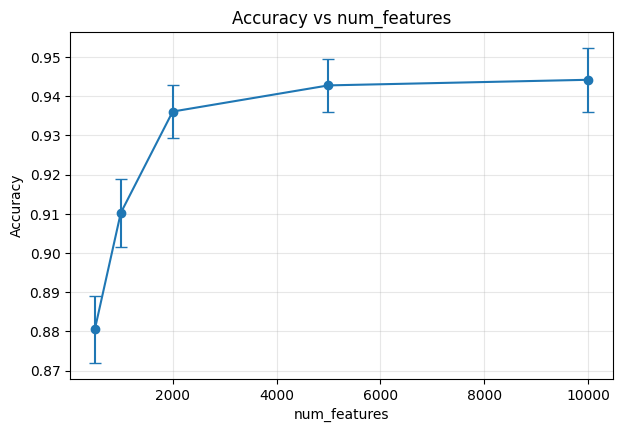

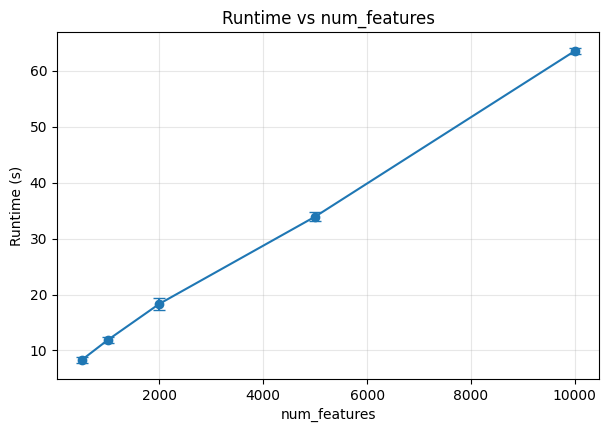

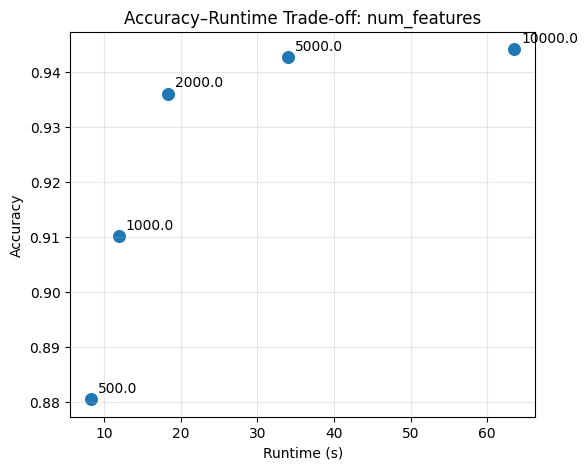

/tmp/ipykernel_250/3659439275.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=[str(v) for v in values], showfliers=True)


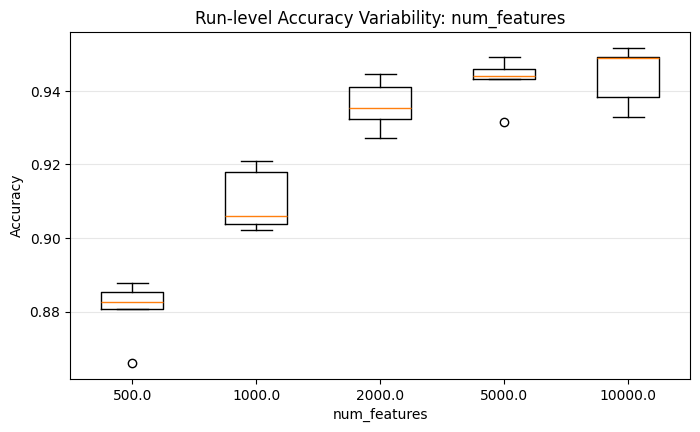

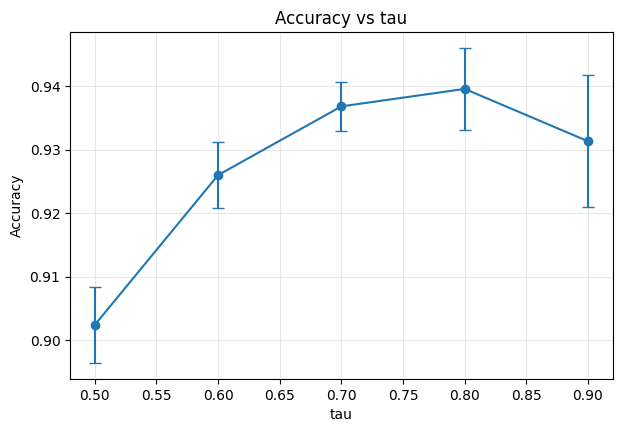

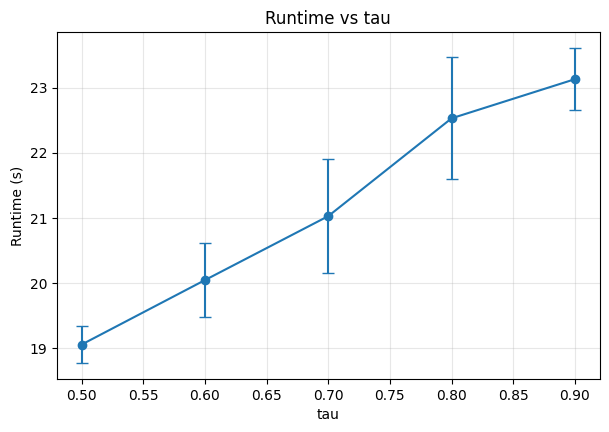

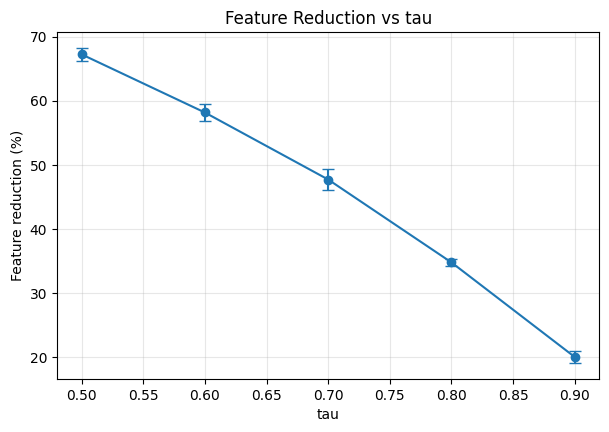

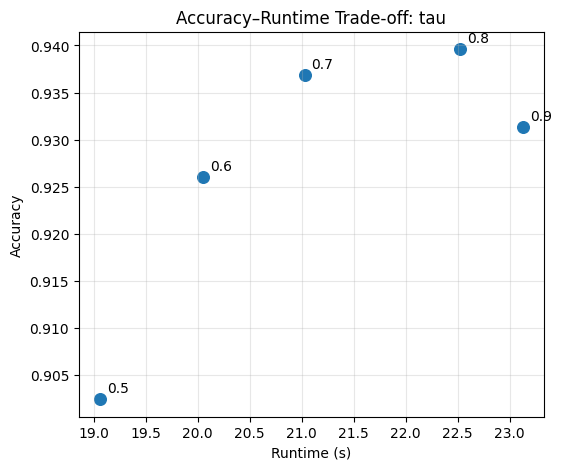

/tmp/ipykernel_250/3659439275.py:107: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grouped, labels=[str(v) for v in values], showfliers=True)


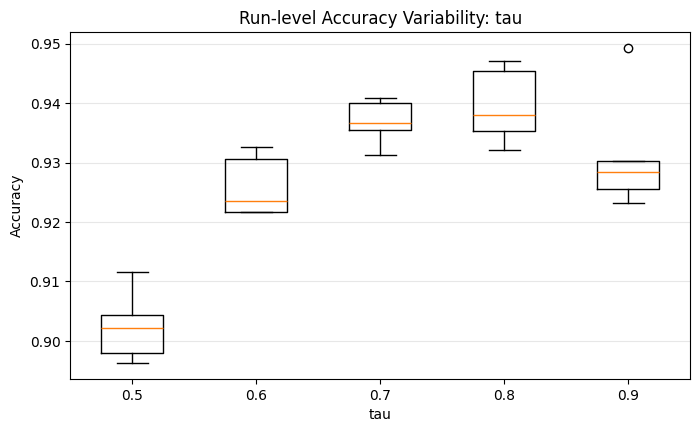

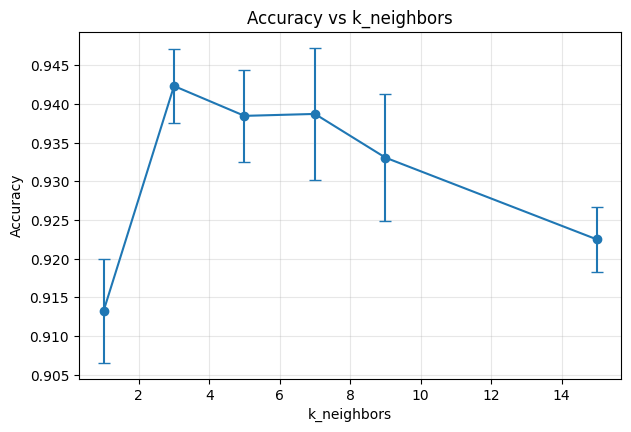

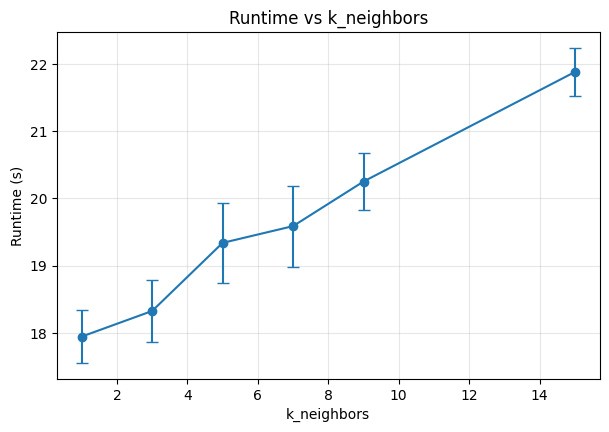

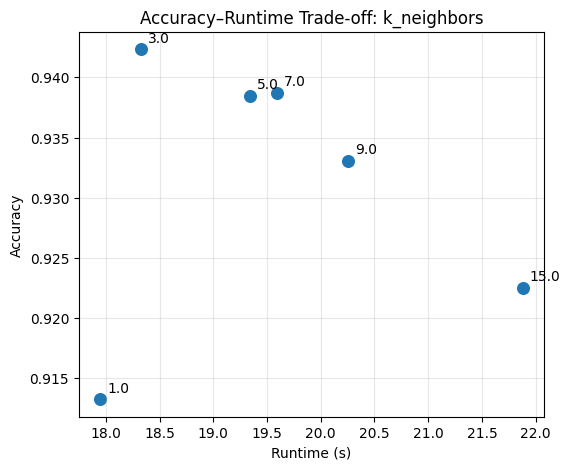

In [ ]:
# num_features
plot_accuracy_vs_parameter(plot_df, "num_features")
plot_runtime_vs_parameter(plot_df, "num_features")
plot_accuracy_runtime_tradeoff(plot_df, "num_features")
plot_run_level_boxplot(results_df, "num_features")

# tau
plot_accuracy_vs_parameter(plot_df, "tau")
plot_runtime_vs_parameter(plot_df, "tau")
plot_reduction_vs_parameter(plot_df, "tau")
plot_accuracy_runtime_tradeoff(plot_df, "tau")
plot_run_level_boxplot(results_df, "tau")

# k_neighbors
plot_accuracy_vs_parameter(plot_df, "k_neighbors")
plot_runtime_vs_parameter(plot_df, "k_neighbors")
plot_accuracy_runtime_tradeoff(plot_df, "k_neighbors")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def _annotate_points(ax, x, y, fmt="{:.3f}", y_offset_frac=0.02):
    """
    Put value labels above each point.
    y_offset_frac is relative to current y-range.
    """
    y = np.asarray(y, dtype=float)
    if len(y) == 0:
        return

    ymin, ymax = np.min(y), np.max(y)
    yrange = ymax - ymin
    if yrange == 0:
        yrange = max(abs(ymax), 1.0)

    offset = y_offset_frac * yrange

    for xi, yi in zip(x, y):
        ax.text(
            xi,
            yi + offset,
            fmt.format(yi),
            ha="center",
            va="bottom",
            fontsize=9
        )

def plot_parameter_effect_combined(plot_df, swept_parameter):
    """
    One figure per parameter:
    - left: accuracy vs parameter
    - right: runtime vs parameter
    with dots and value labels above each dot
    """
    sub = plot_df[plot_df["swept_parameter"] == swept_parameter].copy()
    sub = sub.sort_values("parameter_value")

    x = sub["parameter_value"].values
    acc = sub["accuracy_mean"].values
    acc_std = sub["accuracy_std"].fillna(0).values
    rt = sub["runtime_mean"].values
    rt_std = sub["runtime_std"].fillna(0).values

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    # --------------------------------------------------
    # Accuracy
    # --------------------------------------------------
    axes[0].errorbar(
        x, acc, yerr=acc_std,
        marker="o", linestyle="-", capsize=4
    )
    axes[0].set_xlabel(swept_parameter)
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title(f"Accuracy vs {swept_parameter}")
    axes[0].grid(True, alpha=0.3)
    _annotate_points(axes[0], x, acc, fmt="{:.3f}")

    # --------------------------------------------------
    # Runtime
    # --------------------------------------------------
    axes[1].errorbar(
        x, rt, yerr=rt_std,
        marker="o", linestyle="-", capsize=4
    )
    axes[1].set_xlabel(swept_parameter)
    axes[1].set_ylabel("Runtime (s)")
    axes[1].set_title(f"Runtime vs {swept_parameter}")
    axes[1].grid(True, alpha=0.3)
    _annotate_points(axes[1], x, rt, fmt="{:.2f}")

    fig.suptitle(f"Effect of {swept_parameter}", fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def _format_x_labels(values, swept_parameter):
    labels = []
    for v in values:
        if swept_parameter == "num_features":
            if v >= 1000:
                labels.append(f"{int(v/1000)}k" if v % 1000 == 0 else f"{v/1000:.1f}k")
            else:
                labels.append(str(v))
        elif swept_parameter == "threshold_quantile":
            labels.append(f"{v:.3f}")
        else:
            labels.append(str(v))
    return labels

def _annotate_points(ax, x, y, fmt="{:.3f}", y_offset_frac=0.015, color="dimgray"):
    y = np.asarray(y, dtype=float)
    if len(y) == 0:
        return

    ymin, ymax = np.min(y), np.max(y)
    yrange = ymax - ymin
    if yrange == 0:
        yrange = max(abs(ymax), 1.0)

    offset = y_offset_frac * yrange

    for xi, yi in zip(x, y):
        ax.text(
            xi, yi + offset, fmt.format(yi),
            ha="center", va="bottom",
            fontsize=9, color=color
        )
title_dict = {
    "num_features" : "Number of features",
"max_dilations" : "none",
 "threshold_quantile" : "Threshold Quantile",
"k_neighbors" : "Number of neighbors (kNN)",
"tau" : "Tau"
}
def plot_parameter_effect_combined_pretty(plot_df, swept_parameter, selected_value=None):
    sub = plot_df[plot_df["swept_parameter"] == swept_parameter].copy()
    sub = sub.sort_values("parameter_value")

    x = np.arange(len(sub))
    x_values = sub["parameter_value"].values
    x_labels = _format_x_labels(x_values, swept_parameter)

    acc = sub["accuracy_mean"].values
    acc_std = sub["accuracy_std"].fillna(0).values
    rt = sub["runtime_mean"].values
    rt_std = sub["runtime_std"].fillna(0).values

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))

    for ax in axes:
        ax.grid(True, alpha=0.18, linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels)

    # Accuracy
    axes[0].errorbar(
        x, acc, yerr=acc_std,
        marker="o", linestyle="-",
        capsize=3, linewidth=1.5, markersize=6
    )
    axes[0].set_xlabel(title_dict[swept_parameter], fontsize=11)
    axes[0].set_ylabel("Accuracy", fontsize=11)
    # axes[0].set_title(f"Accuracy vs {swept_parameter}", fontsize=12)
    _annotate_points(axes[0], x, acc, fmt="{:.3f}")

    # Runtime
    axes[1].plot(
    x, rt,
    marker="o",
    linestyle="-",
    linewidth=1.5,
    markersize=6
)
    axes[1].set_xlabel(title_dict[swept_parameter], fontsize=11)
    axes[1].set_ylabel("Runtime (s)", fontsize=11)
    # axes[1].set_title(f"Runtime vs {swept_parameter}", fontsize=12)
    _annotate_points(axes[1], x, rt, fmt="{:.2f}")

    # Highlight selected value if provided
    if selected_value is not None:
        sel_idx = np.where(x_values == selected_value)[0]
        if len(sel_idx) > 0:
            i = sel_idx[0]
            axes[0].scatter(x[i], acc[i], s=90, zorder=5)
            axes[1].scatter(x[i], rt[i], s=90, zorder=5)

            axes[0].annotate(
                "selected", (x[i], acc[i]),
                xytext=(0, 18), textcoords="offset points",
                ha="center", fontsize=9
            )
            axes[1].annotate(
                "selected", (x[i], rt[i]),
                xytext=(0, 18), textcoords="offset points",
                ha="center", fontsize=9
            )

    # fig.suptitle(f"Effect of {swept_parameter}", fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def _format_x_labels(values, swept_parameter):
    labels = []
    for v in values:
        if swept_parameter == "num_features":
            if v >= 1000:
                labels.append(f"{int(v/1000)}k" if v % 1000 == 0 else f"{v/1000:.1f}k")
            else:
                labels.append(str(v))
        elif swept_parameter in ["threshold_quantile", "tau"]:
            labels.append(f"{v:.3f}" if swept_parameter == "threshold_quantile" else f"{v:.1f}")
        else:
            labels.append(str(v))
    return labels

def _annotate_points(ax, x, y, fmt="{:.3f}", y_offset_frac=0.015, color="dimgray"):
    y = np.asarray(y, dtype=float)
    if len(y) == 0:
        return

    ymin, ymax = np.min(y), np.max(y)
    yrange = ymax - ymin
    if yrange == 0:
        yrange = max(abs(ymax), 1.0)

    offset = y_offset_frac * yrange

    for xi, yi in zip(x, y):
        ax.text(
            xi, yi + offset, fmt.format(yi),
            ha="center", va="bottom",
            fontsize=9, color=color
        )

def plot_tau_effect_pretty(plot_df, selected_value=0.7):
    sub = plot_df[plot_df["swept_parameter"] == "tau"].copy()
    sub = sub.sort_values("parameter_value")

    x = np.arange(len(sub))
    x_values = sub["parameter_value"].values
    x_labels = _format_x_labels(x_values, "tau")

    acc = sub["accuracy_mean"].values
    acc_std = sub["accuracy_std"].fillna(0).values

    rt = sub["runtime_mean"].values
    rt_std = sub["runtime_std"].fillna(0).values

    red = sub["reduction_mean"].values
    red_std = sub["reduction_std"].fillna(0).values

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

    for ax in axes:
        ax.grid(True, alpha=0.18, linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels)

    # --------------------------------------------------
    # Accuracy
    # --------------------------------------------------
    axes[0].errorbar(
        x, acc, yerr=acc_std,
        marker="o", linestyle="-",
        capsize=3, linewidth=1.5, markersize=6
    )
    axes[0].set_xlabel("tau", fontsize=11)
    axes[0].set_ylabel("Accuracy", fontsize=11)
    # axes[0].set_title("Accuracy vs tau", fontsize=12)
    _annotate_points(axes[0], x, acc, fmt="{:.3f}")

    # --------------------------------------------------
    # Runtime
    # --------------------------------------------------
    axes[1].errorbar(
        x, rt, yerr=rt_std,
        marker="o", linestyle="-",
        capsize=3, linewidth=1.5, markersize=6
    )
    axes[1].set_xlabel("tau", fontsize=11)
    axes[1].set_ylabel("Runtime (s)", fontsize=11)
    # axes[1].set_title("Runtime vs tau", fontsize=12)
    _annotate_points(axes[1], x, rt, fmt="{:.2f}")

    # --------------------------------------------------
    # Feature reduction
    # --------------------------------------------------
    axes[2].errorbar(
        x, red, yerr=red_std,
        marker="o", linestyle="-",
        capsize=3, linewidth=1.5, markersize=6
    )
    axes[2].set_xlabel("tau", fontsize=11)
    axes[2].set_ylabel("Feature reduction (%)", fontsize=11)
    # axes[2].set_title("Reduction vs tau", fontsize=12)
    _annotate_points(axes[2], x, red, fmt="{:.1f}")

    # --------------------------------------------------
    # Highlight selected tau
    # --------------------------------------------------
    sel_idx = np.where(np.isclose(x_values, selected_value))[0]
    if len(sel_idx) > 0:
        i = sel_idx[0]

        axes[0].scatter(x[i], acc[i], s=90, zorder=5)
        axes[1].scatter(x[i], rt[i], s=90, zorder=5)
        axes[2].scatter(x[i], red[i], s=90, zorder=5)

        axes[0].annotate("selected", (x[i], acc[i]), xytext=(0, 18),
                         textcoords="offset points", ha="center", fontsize=9)
        axes[1].annotate("selected", (x[i], rt[i]), xytext=(0, 18),
                         textcoords="offset points", ha="center", fontsize=9)
        axes[2].annotate("selected", (x[i], red[i]), xytext=(0, 18),
                         textcoords="offset points", ha="center", fontsize=9)

    # fig.suptitle("Effect of tau", fontsize=13)
    plt.tight_layout()
    plt.show()

In [ ]:
import pandas as pd

# --------------------------------------------------
# LOAD REAL RESULTS
# --------------------------------------------------
results_df = pd.read_csv("parameter_sweep_runs.csv")
plot_df = pd.read_csv("parameter_sweep_summary.csv")

print(results_df.head())
print()
print(plot_df.head())

   accuracy  runtime_sec  threshold  num_kept_kernels  full_features  \
0  0.965659    13.762107   1.303040                64            420   
1  0.978350    13.315228   1.248715                64            420   
2  0.974617    13.240916   1.290198                63            420   
3  0.975737    13.304009   1.221483                64            420   
4  0.976297    12.953034   1.284945                62            420   

   kept_features  feature_reduction_pct  run swept_parameter  parameter_value  \
0            320              23.809524    0    num_features            500.0   
1            320              23.809524    1    num_features            500.0   
2            315              25.000000    2    num_features            500.0   
3            320              23.809524    3    num_features            500.0   
4            310              26.190476    4    num_features            500.0   

   num_features  max_dilations  tau  threshold_quantile  k_neighbors  
0        

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_accuracy_runtime_tradeoff_pretty(plot_df, swept_parameter, selected_value=None):
    sub = plot_df[plot_df["swept_parameter"] == swept_parameter].copy()
    sub = sub.sort_values("parameter_value")

    x_values = sub["parameter_value"].values
    acc = sub["accuracy_mean"].values
    rt = sub["runtime_mean"].values

    # --------------------------------------------------
    # label formatting
    # --------------------------------------------------
    labels = []
    for v in x_values:
        if swept_parameter == "num_features":
            if v >= 1000:
                labels.append(f"{int(v/1000)}k" if v % 1000 == 0 else f"{v/1000:.1f}k")
            else:
                labels.append(str(v))
        elif swept_parameter == "threshold_quantile":
            labels.append(f"{v:.3f}")
        elif swept_parameter == "tau":
            labels.append(f"{v:.1f}")
        else:
            labels.append(str(v))

    plt.figure(figsize=(7.5,5))

    # --------------------------------------------------
    # connect the dots
    # --------------------------------------------------
    plt.plot(rt, acc, linewidth=1.6, color="#00509d")

    # scatter points
    plt.scatter(rt, acc, s=70, color="#00509d")

    # --------------------------------------------------
    # label points
    # --------------------------------------------------
    y_min, y_max = np.min(acc), np.max(acc)
    y_range = y_max - y_min
    if y_range == 0:
        y_range = max(abs(y_max), 1.0)

    offset = 0.02 * y_range

    for xi, yi, lab in zip(rt, acc, labels):
        plt.text(
            xi,
            yi + offset,
            lab,
            ha="center",
            fontsize=9,
            color="dimgray"
        )

    # --------------------------------------------------
    # highlight selected point
    # --------------------------------------------------
    if selected_value is not None:
        sel_idx = np.where(np.isclose(x_values.astype(float), float(selected_value)))[0]

        if len(sel_idx) > 0:
            i = sel_idx[0]

            plt.scatter(
                rt[i],
                acc[i],
                s=120,
                color="#fdc500",
                zorder=5
            )

            plt.annotate(
                "selected",
                (rt[i], acc[i]),
                xytext=(0,18),
                textcoords="offset points",
                ha="center",
                fontsize=9
            )

    # --------------------------------------------------
    # axis style
    # --------------------------------------------------
    plt.xlabel("Runtime (s)")
    plt.ylabel("Accuracy")
    # plt.title(f"Accuracy–Runtime Trade-off ({swept_parameter})")

    ax = plt.gca()
    ax.grid(True, alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()




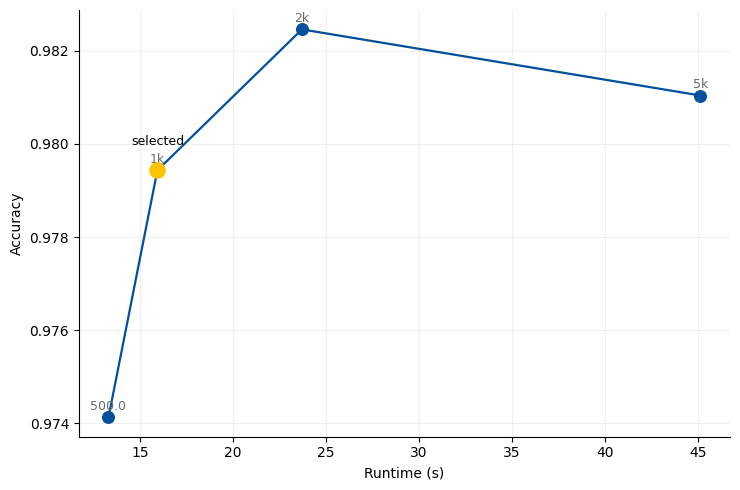

In [ ]:
plot_accuracy_runtime_tradeoff_pretty(plot_df, "num_features", selected_value=1000)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_threshold_quantile_effect_pretty(plot_df, selected_value=None):

    sub = plot_df[plot_df["swept_parameter"] == "threshold_quantile"].copy()
    sub = sub.sort_values("parameter_value")

    x_values = sub["parameter_value"].values
    acc = sub["accuracy_mean"].values
    acc_std = sub["accuracy_std"].fillna(0).values

    x = np.arange(len(x_values))
    x_labels = [f"{v:.3f}" for v in x_values]

    fig, ax = plt.subplots(figsize=(7.5,5))

    # --------------------------------------------------
    # accuracy curve
    # --------------------------------------------------
    ax.errorbar(
        x,
        acc,
        yerr=acc_std,
        marker="o",
        linestyle="-",
        capsize=3,
        linewidth=1.6,
        markersize=6,
        color="#00509d"
    )

    # --------------------------------------------------
    # annotate values
    # --------------------------------------------------
    ymin, ymax = np.min(acc), np.max(acc)
    yrange = ymax - ymin
    if yrange == 0:
        yrange = max(abs(ymax), 1.0)

    offset = 0.02 * yrange

    for xi, yi in zip(x, acc):
        ax.text(
            xi,
            yi + offset,
            f"{yi:.3f}",
            ha="center",
            fontsize=9,
            color="dimgray"
        )

    # --------------------------------------------------
    # highlight selected value
    # --------------------------------------------------
    if selected_value is not None:

        sel_idx = np.where(np.isclose(x_values, selected_value))[0]

        if len(sel_idx) > 0:
            i = sel_idx[0]

            ax.scatter(
                x[i],
                acc[i],
                s=120,
                color="#fdc500",
                zorder=5
            )

            ax.annotate(
                "selected",
                (x[i], acc[i]),
                xytext=(0,18),
                textcoords="offset points",
                ha="center",
                fontsize=9
            )

    # --------------------------------------------------
    # axis styling
    # --------------------------------------------------
    ax.set_xlabel("Threshold quantile")
    ax.set_ylabel("Accuracy")

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)

    ax.grid(True, alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

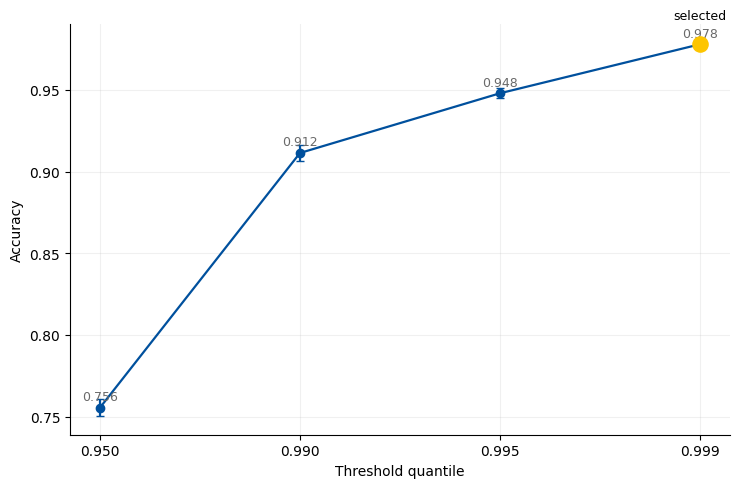

In [ ]:
plot_threshold_quantile_effect_pretty(plot_df, selected_value=0.999)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_k_neighbors_effect_pretty(plot_df, selected_value=None):

    sub = plot_df[plot_df["swept_parameter"] == "k_neighbors"].copy()
    sub = sub.sort_values("parameter_value")

    x_values = sub["parameter_value"].values
    acc = sub["accuracy_mean"].values
    acc_std = sub["accuracy_std"].fillna(0).values

    x = np.arange(len(x_values))
    x_labels = [str(v) for v in x_values]

    fig, ax = plt.subplots(figsize=(7.5,5))

    # --------------------------------------------------
    # accuracy curve
    # --------------------------------------------------
    ax.errorbar(
        x,
        acc,
        yerr=acc_std,
        marker="o",
        linestyle="-",
        capsize=3,
        linewidth=1.6,
        markersize=6,
        color="#00509d"
    )

    # --------------------------------------------------
    # annotate accuracy values
    # --------------------------------------------------
    ymin, ymax = np.min(acc), np.max(acc)
    yrange = ymax - ymin
    if yrange == 0:
        yrange = max(abs(ymax), 1.0)

    offset = 0.02 * yrange

    for xi, yi in zip(x, acc):
        ax.text(
            xi,
            yi + offset,
            f"{yi:.3f}",
            ha="center",
            fontsize=9,
            color="dimgray"
        )

    # --------------------------------------------------
    # highlight selected k
    # --------------------------------------------------
    if selected_value is not None:

        sel_idx = np.where(x_values == selected_value)[0]

        if len(sel_idx) > 0:
            i = sel_idx[0]

            ax.scatter(
                x[i],
                acc[i],
                s=120,
                color="#fdc500",
                zorder=5
            )

            ax.annotate(
                "selected",
                (x[i], acc[i]),
                xytext=(0,18),
                textcoords="offset points",
                ha="center",
                fontsize=9
            )

    # --------------------------------------------------
    # axis styling
    # --------------------------------------------------
    ax.set_xlabel("Number of neighbors (k)")
    ax.set_ylabel("Accuracy")

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)

    ax.grid(True, alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    plt.tight_layout()
    plt.show()

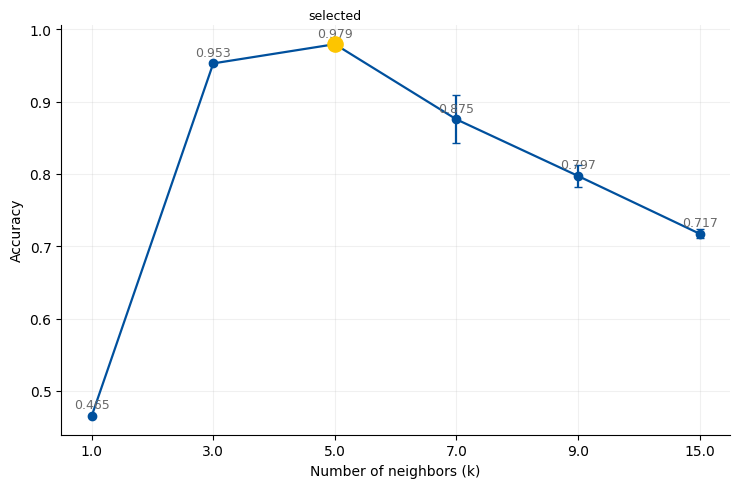

In [ ]:
plot_k_neighbors_effect_pretty(plot_df, selected_value=5)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_tau_tradeoff_3way_pretty(plot_df, selected_value=None):
    sub = plot_df[plot_df["swept_parameter"] == "tau"].copy()
    sub = sub.sort_values("parameter_value")

    tau_vals = sub["parameter_value"].values
    acc = sub["accuracy_mean"].values
    rt = sub["runtime_mean"].values
    red = sub["reduction_mean"].values

    labels = [f"{v:.1f}" for v in tau_vals]

    fig, ax = plt.subplots(figsize=(8, 5.5))

    # --------------------------------------------------
    # connect points in tau order
    # --------------------------------------------------
    ax.plot(rt, acc, linewidth=1.4, color="#00509d", alpha=0.7)

    # --------------------------------------------------
    # scatter with color = reduction ratio
    # --------------------------------------------------
    sc = ax.scatter(
        rt,
        acc,
        c=red,
        s=90,
        cmap="cividis",
        edgecolors="black",
        linewidths=0.5,
        zorder=3
    )

    # --------------------------------------------------
    # annotate tau values
    # --------------------------------------------------
    y_min, y_max = np.min(acc), np.max(acc)
    y_range = y_max - y_min
    if y_range == 0:
        y_range = max(abs(y_max), 1.0)
    offset = 0.02 * y_range

    for xi, yi, lab in zip(rt, acc, labels):
        ax.text(
            xi,
            yi + offset,
            lab,
            ha="center",
            va="bottom",
            fontsize=9,
            color="dimgray"
        )

    # --------------------------------------------------
    # highlight selected tau
    # --------------------------------------------------
    if selected_value is not None:
        sel_idx = np.where(np.isclose(tau_vals.astype(float), float(selected_value)))[0]
        if len(sel_idx) > 0:
            i = sel_idx[0]

            ax.scatter(
                rt[i],
                acc[i],
                s=150,
                color="#fdc500",
                edgecolors="black",
                linewidths=0.8,
                zorder=5
            )

            ax.annotate(
                "selected",
                (rt[i], acc[i]),
                xytext=(0, 18),
                textcoords="offset points",
                ha="center",
                fontsize=9
            )

    # --------------------------------------------------
    # axes and style
    # --------------------------------------------------
    ax.set_xlabel("Runtime (s)")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # colorbar for reduction ratio
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label("Feature reduction (%)")

    plt.tight_layout()
    plt.show()

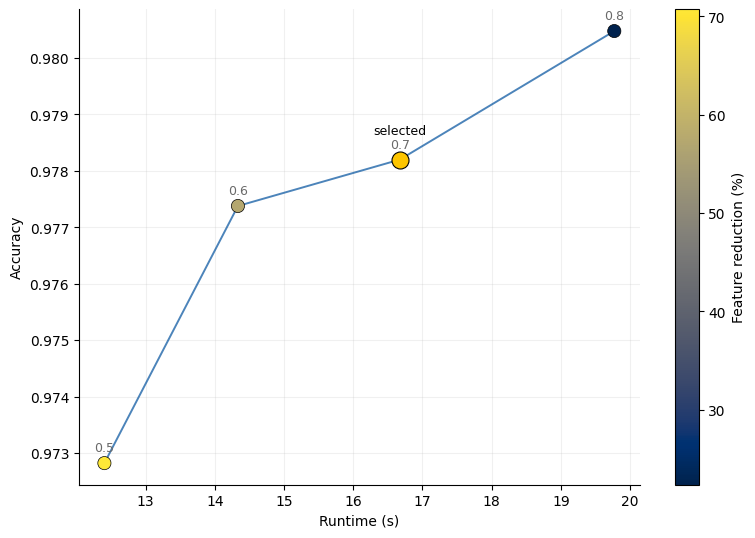

In [ ]:
plot_tau_tradeoff_3way_pretty(plot_df, selected_value=0.7)

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

# ============================================================
# SETTINGS
# ============================================================
NUM_FEATURES = 1000
MAX_DILATIONS = 32
TAU = 0.7
THRESHOLD_QUANTILE = 0.999
K_NEIGHBORS = 5
N_RUNS = 15

SAVE_RUNS_CSV = "minirocket_knn_variants_results.csv"

# ============================================================
# PIPELINE FUNCTION
# ============================================================

def run_pipeline(Xtr, Xte, use_kernel_selection):

    params = fit(
        Xtr.astype(np.float32),
        num_features=NUM_FEATURES,
        max_dilations_per_kernel=MAX_DILATIONS
    )

    _, _, dilations, num_features_per_dilation, _ = params

    Ztr_full = transform(Xtr.astype(np.float32), params).astype(np.float32)
    Zte_full = transform(Xte.astype(np.float32), params).astype(np.float32)

    if use_kernel_selection:

        S = kernel_signatures(Ztr_full, num_features_per_dilation)

        kept_kernels = prune_correlated_kernels(
            S,
            y=None,
            tau=TAU,
            method="variance"
        )

        kept_cols = kept_kernel_feature_cols(
            kept_kernels,
            num_features_per_dilation
        )

        Ztr = Ztr_full[:, kept_cols]
        Zte = Zte_full[:, kept_cols]

    else:

        Ztr = Ztr_full
        Zte = Zte_full
        kept_kernels = None

    # --------------------------------------------------------
    # KNN
    # --------------------------------------------------------

    k = min(int(K_NEIGHBORS), max(2, Ztr.shape[0]))

    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(Ztr)

    d_train, _ = nn.kneighbors(Ztr)
    d_test, _ = nn.kneighbors(Zte)

    train_scores = d_train.mean(axis=1).astype(np.float32)
    test_scores = d_test.mean(axis=1).astype(np.float32)

    threshold = np.quantile(train_scores, THRESHOLD_QUANTILE)

    y_pred = (test_scores > threshold).astype(np.int64)

    return Ztr_full, Ztr, test_scores, y_pred, threshold, kept_kernels


# ============================================================
# RUNS
# ============================================================

run_rows = []

for run_idx in range(N_RUNS):

    print(f"\n================ RUN {run_idx+1}/{N_RUNS} ================")

    # ============================================================
    # V1 : channel selection + kernel selection
    # ============================================================

    t0 = time.perf_counter()

    Zfull, Ztr, scores, y_pred, thr, kept_kernels = run_pipeline(
        X_train_sel, X_test_sel, True
    )

    runtime = time.perf_counter() - t0

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, scores)

    D_full = Zfull.shape[1]
    D_kept = Ztr.shape[1]

    reduction = 100 * (1 - D_kept / D_full)

    run_rows.append({
        "run": run_idx+1,
        "variant": "v1_channel+kernel",
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "runtime_sec": runtime,
        "feature_reduction_pct": reduction,
        "num_channels": X_train_sel.shape[1],
        "num_kernels": len(kept_kernels) if kept_kernels is not None else 0
    })


    # ============================================================
    # V2 : channel selection only (NO kernel selection)
    # ============================================================

    t0 = time.perf_counter()

    Zfull, Ztr, scores, y_pred, thr, _ = run_pipeline(
        X_train_sel, X_test_sel, False
    )

    runtime = time.perf_counter() - t0

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, scores)

    run_rows.append({
        "run": run_idx+1,
        "variant": "v2_channel_only",
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "runtime_sec": runtime,
        "feature_reduction_pct": 0.0,
        "num_channels": X_train_sel.shape[1],
        "num_kernels": Ztr.shape[1]
    })


    # ============================================================
    # V3 : no channel selection + no kernel selection
    # ============================================================

    t0 = time.perf_counter()

    Zfull, Ztr, scores, y_pred, thr, _ = run_pipeline(
        X_train, X_test, False
    )

    runtime = time.perf_counter() - t0

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, scores)

    run_rows.append({
        "run": run_idx+1,
        "variant": "v3_no_selection",
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "runtime_sec": runtime,
        "feature_reduction_pct": 0.0,
        "num_channels": X_train.shape[1],
        "num_kernels": Ztr.shape[1]
    })


# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(run_rows)

print("\n================ ALL RUNS ================")
print(results_df)

# ============================================================
# SUMMARY PER VARIANT
# ============================================================

summary = results_df.groupby("variant").agg({
    "accuracy":["mean","std"],
    "precision":["mean","std"],
    "recall":["mean","std"],
    "f1":["mean","std"],
    "auc":["mean","std"],
    "runtime_sec":["mean","std"],
    "feature_reduction_pct":["mean","std"]
})

print("\n================ SUMMARY ================")
print(summary)

# ============================================================
# SAVE
# ============================================================

results_df.to_csv(SAVE_RUNS_CSV, index=False)

print("\nSaved results:", SAVE_RUNS_CSV)



================ RUN 1/15 ================


ValueError: Found input variables with inconsistent numbers of samples: [5330, 5358]

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

# ============================================================
# SETTINGS
# ============================================================
NUM_FEATURES = 1000
MAX_DILATIONS = 32
TAU = 0.7
THRESHOLD_QUANTILE = 0.999
K_NEIGHBORS = 5
N_RUNS = 15

SAVE_RUNS_CSV = "minirocket_knn_variants_results.csv"

# ============================================================
# PIPELINE FUNCTION
# ============================================================

def run_pipeline(Xtr, Xte, use_kernel_selection):

    params = fit(
        Xtr.astype(np.float32),
        num_features=NUM_FEATURES,
        max_dilations_per_kernel=MAX_DILATIONS
    )

    _, _, dilations, num_features_per_dilation, _ = params

    Ztr_full = transform(Xtr.astype(np.float32), params).astype(np.float32)
    Zte_full = transform(Xte.astype(np.float32), params).astype(np.float32)

    if use_kernel_selection:

        S = kernel_signatures(Ztr_full, num_features_per_dilation)

        kept_kernels = prune_correlated_kernels(
            S,
            y=None,
            tau=TAU,
            method="variance"
        )

        kept_cols = kept_kernel_feature_cols(
            kept_kernels,
            num_features_per_dilation
        )

        Ztr = Ztr_full[:, kept_cols]
        Zte = Zte_full[:, kept_cols]

    else:

        Ztr = Ztr_full
        Zte = Zte_full
        kept_kernels = None

    # --------------------------------------------------------
    # KNN
    # --------------------------------------------------------

    k = min(int(K_NEIGHBORS), max(2, Ztr.shape[0]))

    nn = NearestNeighbors(n_neighbors=k, metric="euclidean")
    nn.fit(Ztr)

    d_train, _ = nn.kneighbors(Ztr)
    d_test, _ = nn.kneighbors(Zte)

    train_scores = d_train.mean(axis=1).astype(np.float32)
    test_scores = d_test.mean(axis=1).astype(np.float32)

    threshold = np.quantile(train_scores, THRESHOLD_QUANTILE)

    y_pred = (test_scores > threshold).astype(np.int64)

    return Ztr_full, Ztr, test_scores, y_pred, threshold, kept_kernels


# ============================================================
# RUNS
# ============================================================

run_rows = []

for run_idx in range(N_RUNS):

    print(f"\n================ RUN {run_idx+1}/{N_RUNS} ================")

    # ============================================================
    # V1 : channel selection + kernel selection
    # ============================================================

    t0 = time.perf_counter()

    Zfull, Ztr, scores, y_pred, thr, kept_kernels = run_pipeline(
        X_train_sel, X_test_sel, True
    )

    runtime = time.perf_counter() - t0

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, scores)

    D_full = Zfull.shape[1]
    D_kept = Ztr.shape[1]

    reduction = 100 * (1 - D_kept / D_full)

    run_rows.append({
        "run": run_idx+1,
        "variant": "v1_channel+kernel",
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "runtime_sec": runtime,
        "feature_reduction_pct": reduction,
        "num_channels": X_train_sel.shape[1],
        "num_kernels": len(kept_kernels) if kept_kernels is not None else 0
    })


    # ============================================================
    # V2 : channel selection only (NO kernel selection)
    # ============================================================

    t0 = time.perf_counter()

    Zfull, Ztr, scores, y_pred, thr, _ = run_pipeline(
        X_train_sel, X_test_sel, False
    )

    runtime = time.perf_counter() - t0

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, scores)

    run_rows.append({
        "run": run_idx+1,
        "variant": "v2_channel_only",
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "runtime_sec": runtime,
        "feature_reduction_pct": 0.0,
        "num_channels": X_train_sel.shape[1],
        "num_kernels": Ztr.shape[1]
    })


    # ============================================================
    # V3 : no channel selection + no kernel selection
    # ============================================================

    t0 = time.perf_counter()

    Zfull, Ztr, scores, y_pred, thr, _ = run_pipeline(
        X_train, X_test, False
    )

    runtime = time.perf_counter() - t0

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, scores)

    run_rows.append({
        "run": run_idx+1,
        "variant": "v3_no_selection",
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "runtime_sec": runtime,
        "feature_reduction_pct": 0.0,
        "num_channels": X_train.shape[1],
        "num_kernels": Ztr.shape[1]
    })


# ============================================================
# RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(run_rows)

print("\n================ ALL RUNS ================")
print(results_df)

# ============================================================
# SUMMARY PER VARIANT
# ============================================================

summary = results_df.groupby("variant").agg({
    "accuracy":["mean","std"],
    "precision":["mean","std"],
    "recall":["mean","std"],
    "f1":["mean","std"],
    "auc":["mean","std"],
    "runtime_sec":["mean","std"],
    "feature_reduction_pct":["mean","std"]
})

print("\n================ SUMMARY ================")
print(summary)

# ============================================================
# SAVE
# ============================================================

results_df.to_csv(SAVE_RUNS_CSV, index=False)

print("\nSaved results:", SAVE_RUNS_CSV)



================ RUN 1/15 ================

================ RUN 2/15 ================

================ RUN 3/15 ================

================ RUN 4/15 ================

================ RUN 5/15 ================

================ RUN 6/15 ================

================ RUN 7/15 ================

================ RUN 8/15 ================

================ RUN 9/15 ================

================ RUN 10/15 ================

================ RUN 11/15 ================

================ RUN 12/15 ================

================ RUN 13/15 ================

================ RUN 14/15 ================

================ RUN 15/15 ================

================ ALL RUNS ================
    run            variant  accuracy  precision    recall        f1       auc  \
0     1  v1_channel+kernel  0.972795   0.971158  0.966581  0.968864  0.988871   
1     1    v2_channel_only  0.977111   0.972246  0.975578  0.973909  0.990197   
2     1    v3_no_selection  0.974672   0.968072

In [ ]:
import copy
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# Dataset
# ============================================================
class SequenceDataset(Dataset):
    def __init__(self, X):
        """
        X: numpy array or torch tensor of shape (N, T, D)
        """
        if isinstance(X, np.ndarray):
            X = torch.tensor(X, dtype=torch.float32)
        elif not torch.is_tensor(X):
            raise TypeError("X must be a numpy array or torch tensor")

        self.X = X.float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]


# ============================================================
# LSTM Autoencoder
# ============================================================
class LSTMAutoencoder(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dim: int = 64,
        latent_dim: int = 32,
        num_layers: int = 1,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.num_layers = num_layers

        lstm_dropout = dropout if num_layers > 1 else 0.0

        # Encoder
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )

        self.hidden_to_latent = nn.Linear(hidden_dim, latent_dim)

        # Decoder preparation
        self.latent_to_hidden = nn.Linear(latent_dim, hidden_dim)

        # Decoder
        self.decoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout,
        )

        self.output_layer = nn.Linear(hidden_dim, input_dim)

        self.dropout = nn.Dropout(dropout)

    def encode(self, x):
        """
        x: (B, T, D)
        returns:
            z: (B, latent_dim)
        """
        _, (h_n, _) = self.encoder(x)  # h_n: (num_layers, B, hidden_dim)
        h_last = h_n[-1]               # (B, hidden_dim)
        h_last = self.dropout(h_last)
        z = self.hidden_to_latent(h_last)
        return z

    def decode(self, z, seq_len):
        """
        z: (B, latent_dim)
        returns:
            x_hat: (B, T, D)
        """
        hidden = self.latent_to_hidden(z)             # (B, hidden_dim)
        hidden = self.dropout(hidden)

        # Repeat latent-derived hidden state across time
        decoder_input = hidden.unsqueeze(1).repeat(1, seq_len, 1)  # (B, T, hidden_dim)

        decoded_seq, _ = self.decoder(decoder_input)               # (B, T, hidden_dim)
        x_hat = self.output_layer(decoded_seq)                     # (B, T, D)
        return x_hat

    def forward(self, x):
        seq_len = x.size(1)
        z = self.encode(x)
        x_hat = self.decode(z, seq_len)
        return x_hat


# ============================================================
# Standardizer for feature-wise normalization
# ============================================================
class FeatureStandardizer:
    def __init__(self, eps=1e-8):
        self.mean = None
        self.std = None
        self.eps = eps

    def fit(self, X):
        """
        X: numpy array of shape (N, T, D)
        Fit using all values over N and T for each feature D
        """
        if not isinstance(X, np.ndarray):
            X = np.asarray(X, dtype=np.float32)

        self.mean = X.mean(axis=(0, 1), keepdims=True)
        self.std = X.std(axis=(0, 1), keepdims=True)
        self.std = np.where(self.std < self.eps, 1.0, self.std)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# ============================================================
# Training utilities
# ============================================================
def train_lstm_autoencoder(
    model,
    X_train,
    X_val=None,
    batch_size=64,
    epochs=100,
    lr=1e-3,
    weight_decay=1e-5,
    patience=10,
    grad_clip=1.0,
    device=None,
):
    """
    Trains on normal windows only.
    Returns:
        model, history
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    train_loader = DataLoader(
        SequenceDataset(X_train),
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    val_loader = None
    if X_val is not None:
        val_loader = DataLoader(
            SequenceDataset(X_val),
            batch_size=batch_size,
            shuffle=False,
            drop_last=False,
        )

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(1, epochs + 1):
        # -------------------------
        # Train
        # -------------------------
        model.train()
        train_loss_sum = 0.0
        train_count = 0

        for batch in train_loader:
            batch = batch.to(device)

            optimizer.zero_grad()
            recon = model(batch)
            loss = criterion(recon, batch)
            loss.backward()

            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

            bs = batch.size(0)
            train_loss_sum += loss.item() * bs
            train_count += bs

        train_loss = train_loss_sum / max(train_count, 1)
        history["train_loss"].append(train_loss)

        # -------------------------
        # Validation
        # -------------------------
        if val_loader is not None:
            model.eval()
            val_loss_sum = 0.0
            val_count = 0

            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(device)
                    recon = model(batch)
                    loss = criterion(recon, batch)

                    bs = batch.size(0)
                    val_loss_sum += loss.item() * bs
                    val_count += bs

            val_loss = val_loss_sum / max(val_count, 1)
            history["val_loss"].append(val_loss)

            print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print(f"Early stopping at epoch {epoch}")
                    break
        else:
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f}")

    model.load_state_dict(best_state)
    return model, history


# ============================================================
# Scoring
# ============================================================
@torch.no_grad()
def reconstruction_errors(model, X, batch_size=256, device=None):
    """
    Returns per-window reconstruction MSE.
    X shape: (N, T, D)
    Output shape: (N,)
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model.eval()
    model.to(device)

    loader = DataLoader(
        SequenceDataset(X),
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
    )

    all_errors = []

    for batch in loader:
        batch = batch.to(device)
        recon = model(batch)

        # per-window MSE over time and features
        err = ((batch - recon) ** 2).mean(dim=(1, 2))
        all_errors.append(err.cpu())

    return torch.cat(all_errors).numpy()


def fit_threshold(train_errors, percentile=99.0):
    """
    Fit anomaly threshold using normal validation/train errors.
    """
    return float(np.percentile(train_errors, percentile))


def predict_anomalies(errors, threshold):
    return (errors > threshold).astype(np.int64)


# ============================================================
# High-level wrapper
# ============================================================
class LSTMAEAnomalyDetector:
    def __init__(
        self,
        input_dim,
        window_size=64,
        hidden_dim=64,
        latent_dim=32,
        num_layers=1,
        dropout=0.2,
        lr=1e-3,
        batch_size=64,
        epochs=100,
        patience=10,
        weight_decay=1e-5,
        grad_clip=1.0,
        threshold_percentile=99.0,
        device=None,
    ):
        self.window_size = window_size
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.lr = lr
        self.weight_decay = weight_decay
        self.grad_clip = grad_clip
        self.threshold_percentile = threshold_percentile
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.scaler = FeatureStandardizer()
        self.model = LSTMAutoencoder(
            input_dim=input_dim,
            hidden_dim=hidden_dim,
            latent_dim=latent_dim,
            num_layers=num_layers,
            dropout=dropout,
        )
        self.threshold_ = None
        self.history_ = None

    def fit(self, X_train_normal, X_val_normal=None):
        """
        Fit on normal windows only.
        """
        X_train_normal = np.asarray(X_train_normal, dtype=np.float32)
        assert X_train_normal.ndim == 3, "X_train_normal must have shape (N, T, D)"
        assert X_train_normal.shape[1] == self.window_size, "Window size mismatch"

        X_train_scaled = self.scaler.fit_transform(X_train_normal)

        X_val_scaled = None
        if X_val_normal is not None:
            X_val_normal = np.asarray(X_val_normal, dtype=np.float32)
            assert X_val_normal.ndim == 3
            assert X_val_normal.shape[1] == self.window_size
            X_val_scaled = self.scaler.transform(X_val_normal)

        self.model, self.history_ = train_lstm_autoencoder(
            model=self.model,
            X_train=X_train_scaled,
            X_val=X_val_scaled,
            batch_size=self.batch_size,
            epochs=self.epochs,
            lr=self.lr,
            weight_decay=self.weight_decay,
            patience=self.patience,
            grad_clip=self.grad_clip,
            device=self.device,
        )

        # Use validation normal errors if available, otherwise training normal errors
        ref_X = X_val_scaled if X_val_scaled is not None else X_train_scaled
        ref_errors = reconstruction_errors(
            self.model,
            ref_X,
            batch_size=self.batch_size,
            device=self.device,
        )
        self.threshold_ = fit_threshold(ref_errors, percentile=self.threshold_percentile)
        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=np.float32)
        X_scaled = self.scaler.transform(X)
        return reconstruction_errors(
            self.model,
            X_scaled,
            batch_size=self.batch_size,
            device=self.device,
        )

    def predict(self, X):
        errors = self.decision_function(X)
        return predict_anomalies(errors, self.threshold_)

    def fit_predict(self, X_train_normal, X_test):
        self.fit(X_train_normal)
        return self.predict(X_test)

In [ ]:
candidate_configs = [
    {
        "name": "cfg1_small",
        "hidden_dim": 32,
        "latent_dim": 16,
        "num_layers": 1,
        "dropout": 0.0,
        "lr": 1e-3,
        "batch_size": 32,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg2_default",
        "hidden_dim": 64,
        "latent_dim": 32,
        "num_layers": 1,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg3_deeper",
        "hidden_dim": 64,
        "latent_dim": 32,
        "num_layers": 2,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg4_wider",
        "hidden_dim": 128,
        "latent_dim": 32,
        "num_layers": 2,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg5_stronger_bottleneck",
        "hidden_dim": 128,
        "latent_dim": 16,
        "num_layers": 2,
        "dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg6_slower_lr",
        "hidden_dim": 64,
        "latent_dim": 32,
        "num_layers": 2,
        "dropout": 0.2,
        "lr": 1e-4,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
]


In [ ]:
import time
import random
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

candidate_configs = [
    {
        "name": "cfg1_small",
        "hidden_dim": 32,
        "latent_dim": 16,
        "num_layers": 1,
        "dropout": 0.0,
        "lr": 1e-3,
        "batch_size": 32,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg2_default",
        "hidden_dim": 64,
        "latent_dim": 32,
        "num_layers": 1,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg3_deeper",
        "hidden_dim": 64,
        "latent_dim": 32,
        "num_layers": 2,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg4_wider",
        "hidden_dim": 128,
        "latent_dim": 32,
        "num_layers": 2,
        "dropout": 0.2,
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg5_stronger_bottleneck",
        "hidden_dim": 128,
        "latent_dim": 16,
        "num_layers": 2,
        "dropout": 0.3,
        "lr": 1e-3,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
    {
        "name": "cfg6_slower_lr",
        "hidden_dim": 64,
        "latent_dim": 32,
        "num_layers": 2,
        "dropout": 0.2,
        "lr": 1e-4,
        "batch_size": 64,
        "epochs": 100,
        "patience": 10,
        "weight_decay": 1e-5,
        "grad_clip": 5.0,
        "threshold_percentile": 99.0,
    },
]

results = []

for cfg in candidate_configs:
    print("\n==============================")
    print("Running:", cfg["name"])
    print(cfg)

    set_seed(0)

    detector = LSTMAEAnomalyDetector(
        input_dim=INPUT_DIM,
        window_size=WINDOW_SIZE,
        hidden_dim=cfg["hidden_dim"],
        latent_dim=cfg["latent_dim"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        batch_size=cfg["batch_size"],
        epochs=cfg["epochs"],
        patience=cfg["patience"],
        weight_decay=cfg["weight_decay"],
        grad_clip=cfg["grad_clip"],
        threshold_percentile=cfg["threshold_percentile"],
        device=None,
    )

    t0 = time.perf_counter()

    detector.fit(X_train_normal, X_val_normal)

    test_errors = detector.decision_function(X_test_lstm)
    y_pred = predict_anomalies(test_errors, detector.threshold_)

    runtime_sec = time.perf_counter() - t0

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, test_errors)
    cm = confusion_matrix(y_test, y_pred)

    row = {
        "name": cfg["name"],
        "hidden_dim": cfg["hidden_dim"],
        "latent_dim": cfg["latent_dim"],
        "num_layers": cfg["num_layers"],
        "dropout": cfg["dropout"],
        "lr": cfg["lr"],
        "batch_size": cfg["batch_size"],
        "epochs": cfg["epochs"],
        "patience": cfg["patience"],
        "weight_decay": cfg["weight_decay"],
        "grad_clip": cfg["grad_clip"],
        "threshold_percentile": cfg["threshold_percentile"],
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "runtime_sec": runtime_sec,
        "threshold": detector.threshold_,
        "tn": int(cm[0, 0]),
        "fp": int(cm[0, 1]),
        "fn": int(cm[1, 0]),
        "tp": int(cm[1, 1]),
    }

    results.append(row)

    print("Accuracy :", f"{acc:.6f}")
    print("Precision:", f"{precision:.6f}")
    print("Recall   :", f"{recall:.6f}")
    print("F1       :", f"{f1:.6f}")
    print("AUC      :", f"{auc:.6f}")
    print("Runtime  :", f"{runtime_sec:.2f}s")
    print("Threshold:", f"{detector.threshold_:.6f}")
    print("CM:\n", cm)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["auc", "f1", "accuracy"], ascending=False).reset_index(drop=True)

print("\n================ FINAL RESULTS ================")
print(results_df)

# optional save
results_df.to_csv("lstm_ae_config_sweep.csv", index=False)
print("\nSaved: lstm_ae_config_sweep.csv")



Running: cfg1_small
{'name': 'cfg1_small', 'hidden_dim': 32, 'latent_dim': 16, 'num_layers': 1, 'dropout': 0.0, 'lr': 0.001, 'batch_size': 32, 'epochs': 100, 'patience': 10, 'weight_decay': 1e-05, 'grad_clip': 5.0, 'threshold_percentile': 99.0}
Epoch 001 | train_loss=0.866722 | val_loss=0.756719
Epoch 002 | train_loss=0.745351 | val_loss=0.674304
Epoch 003 | train_loss=0.684405 | val_loss=0.629870
Epoch 004 | train_loss=0.650897 | val_loss=0.611916
Epoch 005 | train_loss=0.631029 | val_loss=0.594863
Epoch 006 | train_loss=0.617142 | val_loss=0.579580
Epoch 007 | train_loss=0.602509 | val_loss=0.563659
Epoch 008 | train_loss=0.591621 | val_loss=0.569172
Epoch 009 | train_loss=0.585782 | val_loss=0.551380
Epoch 010 | train_loss=0.576968 | val_loss=0.548581
Epoch 011 | train_loss=0.572748 | val_loss=0.543257
Epoch 012 | train_loss=0.566176 | val_loss=0.547121
Epoch 013 | train_loss=0.562145 | val_loss=0.537447
Epoch 014 | train_loss=0.555854 | val_loss=0.540212
Epoch 015 | train_loss=0.5

In [ ]:
X_train.shape

(11981, 108, 40)

In [ ]:
X_test.shape

(5330, 108, 40)

In [ ]:
import copy
import math
import numpy as np
from dataclasses import dataclass
from typing import Optional, Tuple, Dict, List

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# ============================================================
# Utilities
# ============================================================
LOG_2PI = math.log(2.0 * math.pi)


def set_seed(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def gaussian_log_prob_diag(x: torch.Tensor,
                           mean: torch.Tensor,
                           std: torch.Tensor,
                           eps: float = 1e-8) -> torch.Tensor:
    """
    Elementwise log prob under diagonal Gaussian.
    x, mean, std: (..., D)
    returns: (..., D)
    """
    std = torch.clamp(std, min=eps)
    var = std ** 2
    return -0.5 * (((x - mean) ** 2) / var + 2.0 * torch.log(std) + LOG_2PI)


def gaussian_kl_diag(mu_q: torch.Tensor,
                     std_q: torch.Tensor,
                     mu_p: torch.Tensor,
                     std_p: torch.Tensor,
                     eps: float = 1e-8) -> torch.Tensor:
    """
    KL( q || p ) for diagonal Gaussians.
    Shapes: (..., D)
    returns: (...,)
    """
    std_q = torch.clamp(std_q, min=eps)
    std_p = torch.clamp(std_p, min=eps)

    var_q = std_q ** 2
    var_p = std_p ** 2

    kl = torch.log(std_p / std_q) + (var_q + (mu_q - mu_p) ** 2) / (2.0 * var_p) - 0.5
    return kl.sum(dim=-1)


# ============================================================
# Dataset
# ============================================================
class SequenceDataset(Dataset):
    def __init__(self, X: np.ndarray):
        """
        X shape: (N, T, D)
        """
        X = np.asarray(X, dtype=np.float32)
        if X.ndim != 3:
            raise ValueError("X must have shape (N, T, D)")
        self.X = torch.from_numpy(X)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx]


class StandardScalerTS:
    """
    Per-feature z-score over all windows and time steps.
    """
    def __init__(self, eps: float = 1e-8):
        self.mean_ = None
        self.std_ = None
        self.eps = eps

    def fit(self, X: np.ndarray):
        X = np.asarray(X, dtype=np.float32)
        self.mean_ = X.mean(axis=(0, 1), keepdims=True)
        self.std_ = X.std(axis=(0, 1), keepdims=True)
        self.std_ = np.where(self.std_ < self.eps, 1.0, self.std_)
        return self

    def transform(self, X: np.ndarray):
        X = np.asarray(X, dtype=np.float32)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X: np.ndarray):
        return self.fit(X).transform(X)


# ============================================================
# Planar Flow
# ============================================================
class PlanarFlow(nn.Module):
    """
    z' = z + u * tanh(w^T z + b)
    """
    def __init__(self, dim: int):
        super().__init__()
        self.u = nn.Parameter(torch.randn(dim) * 0.01)
        self.w = nn.Parameter(torch.randn(dim) * 0.01)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, z: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        z: (..., D)
        returns:
            z_new: (..., D)
            log_abs_det_jac: (...,)
        """
        linear = torch.matmul(z, self.w) + self.b  # (...,)
        h = torch.tanh(linear)                      # (...,)
        z_new = z + self.u * h.unsqueeze(-1)       # (..., D)

        psi = (1.0 - torch.tanh(linear) ** 2).unsqueeze(-1) * self.w  # (..., D)
        det_term = 1.0 + torch.sum(psi * self.u, dim=-1)              # (...,)
        log_abs_det_jac = torch.log(torch.abs(det_term) + 1e-8)

        return z_new, log_abs_det_jac


class PlanarFlowStack(nn.Module):
    def __init__(self, dim: int, n_flows: int):
        super().__init__()
        self.flows = nn.ModuleList([PlanarFlow(dim) for _ in range(n_flows)])

    def forward(self, z: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        total_log_det = torch.zeros(z.shape[:-1], device=z.device, dtype=z.dtype)
        out = z
        for flow in self.flows:
            out, log_det = flow(out)
            total_log_det = total_log_det + log_det
        return out, total_log_det


# ============================================================
# OmniAnomaly core model
# ============================================================
class OmniAnomalyModel(nn.Module):
    """
    Faithful PyTorch-style implementation of OmniAnomaly.

    qnet:
      x_t, h_{t-1} -> GRU -> e_t
      [z_{t-1}, e_t] -> dense -> mu_z_t, std_z_t
      sample z0_t -> planar flows -> z_t

    pnet:
      z_t, d_{t-1} -> GRU -> d_t
      d_t -> dense -> mu_x_t, std_x_t

    prior:
      z_{t-1} -> mu_p_t, std_p_t
      p(z_t | z_{t-1})

    The paper uses reconstruction probability for anomaly score and
    models temporal dependence among z variables. :contentReference[oaicite:1]{index=1}
    """
    def __init__(
        self,
        x_dim: int,
        z_dim: int = 3,
        rnn_hidden_dim: int = 500,
        dense_dim: int = 500,
        n_flows: int = 20,
        std_epsilon: float = 1e-4,
        use_planar_flows: bool = True,
    ):
        super().__init__()
        self.x_dim = x_dim
        self.z_dim = z_dim
        self.rnn_hidden_dim = rnn_hidden_dim
        self.dense_dim = dense_dim
        self.std_epsilon = std_epsilon
        self.use_planar_flows = use_planar_flows

        # qnet GRU cell
        self.q_gru = nn.GRUCell(input_size=x_dim, hidden_size=rnn_hidden_dim)

        # qnet heads
        self.q_dense = nn.Sequential(
            nn.Linear(rnn_hidden_dim + z_dim, dense_dim),
            nn.ReLU(),
        )
        self.q_mu = nn.Linear(dense_dim, z_dim)
        self.q_std = nn.Linear(dense_dim, z_dim)

        # prior p(z_t | z_{t-1})
        self.p_z_dense = nn.Sequential(
            nn.Linear(z_dim, dense_dim),
            nn.ReLU(),
        )
        self.p_z_mu = nn.Linear(dense_dim, z_dim)
        self.p_z_std = nn.Linear(dense_dim, z_dim)

        # pnet GRU cell
        self.p_gru = nn.GRUCell(input_size=z_dim, hidden_size=rnn_hidden_dim)

        # pnet heads
        self.p_x_dense = nn.Sequential(
            nn.Linear(rnn_hidden_dim, dense_dim),
            nn.ReLU(),
        )
        self.p_x_mu = nn.Linear(dense_dim, x_dim)
        self.p_x_std = nn.Linear(dense_dim, x_dim)

        # flows
        self.flow = PlanarFlowStack(z_dim, n_flows) if use_planar_flows and n_flows > 0 else None

    def _softplus_std(self, raw: torch.Tensor) -> torch.Tensor:
        return F.softplus(raw) + self.std_epsilon

    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        """
        x: (B, T, D)

        returns dict with:
          mu_z, std_z, z0, z, flow_log_det
          mu_p, std_p
          mu_x, std_x
          recon_log_prob_per_dim: (B, T, D)
          recon_log_prob: (B, T)
          kl: (B, T)
          elbo_t: (B, T)
        """
        B, T, D = x.shape
        device = x.device

        e_t = torch.zeros(B, self.rnn_hidden_dim, device=device)
        d_t = torch.zeros(B, self.rnn_hidden_dim, device=device)
        z_prev = torch.zeros(B, self.z_dim, device=device)

        mu_z_list, std_z_list = [], []
        z0_list, z_list, flow_logdet_list = [], [], []
        mu_p_list, std_p_list = [], []
        mu_x_list, std_x_list = [], []
        recon_log_prob_dim_list = []
        recon_log_prob_list = []
        kl_list = []
        elbo_t_list = []

        for t in range(T):
            x_t = x[:, t, :]

            # qnet
            e_t = self.q_gru(x_t, e_t)
            q_in = torch.cat([z_prev, e_t], dim=-1)
            q_h = self.q_dense(q_in)
            mu_z_t = self.q_mu(q_h)
            std_z_t = self._softplus_std(self.q_std(q_h))

            eps = torch.randn_like(std_z_t)
            z0_t = mu_z_t + eps * std_z_t

            if self.flow is not None:
                z_t, flow_log_det_t = self.flow(z0_t)
            else:
                z_t = z0_t
                flow_log_det_t = torch.zeros(B, device=device)

            # prior p(z_t | z_{t-1})
            p_h = self.p_z_dense(z_prev)
            mu_p_t = self.p_z_mu(p_h)
            std_p_t = self._softplus_std(self.p_z_std(p_h))

            # pnet
            d_t = self.p_gru(z_t, d_t)
            p_x_h = self.p_x_dense(d_t)
            mu_x_t = self.p_x_mu(p_x_h)
            std_x_t = self._softplus_std(self.p_x_std(p_x_h))

            # reconstruction log prob
            recon_log_prob_dim_t = gaussian_log_prob_diag(x_t, mu_x_t, std_x_t)
            recon_log_prob_t = recon_log_prob_dim_t.sum(dim=-1)

            # KL term
            # Approximate q(z_t | .) as transformed posterior.
            # Practical implementation uses base Gaussian KL minus flow log-det.
            kl_t = gaussian_kl_diag(mu_z_t, std_z_t, mu_p_t, std_p_t) - flow_log_det_t

            elbo_t = recon_log_prob_t - kl_t

            # store
            mu_z_list.append(mu_z_t)
            std_z_list.append(std_z_t)
            z0_list.append(z0_t)
            z_list.append(z_t)
            flow_logdet_list.append(flow_log_det_t)
            mu_p_list.append(mu_p_t)
            std_p_list.append(std_p_t)
            mu_x_list.append(mu_x_t)
            std_x_list.append(std_x_t)
            recon_log_prob_dim_list.append(recon_log_prob_dim_t)
            recon_log_prob_list.append(recon_log_prob_t)
            kl_list.append(kl_t)
            elbo_t_list.append(elbo_t)

            z_prev = z_t

        out = {
            "mu_z": torch.stack(mu_z_list, dim=1),
            "std_z": torch.stack(std_z_list, dim=1),
            "z0": torch.stack(z0_list, dim=1),
            "z": torch.stack(z_list, dim=1),
            "flow_log_det": torch.stack(flow_logdet_list, dim=1),
            "mu_p": torch.stack(mu_p_list, dim=1),
            "std_p": torch.stack(std_p_list, dim=1),
            "mu_x": torch.stack(mu_x_list, dim=1),
            "std_x": torch.stack(std_x_list, dim=1),
            "recon_log_prob_per_dim": torch.stack(recon_log_prob_dim_list, dim=1),
            "recon_log_prob": torch.stack(recon_log_prob_list, dim=1),
            "kl": torch.stack(kl_list, dim=1),
            "elbo_t": torch.stack(elbo_t_list, dim=1),
        }
        return out

    def loss(self, x: torch.Tensor) -> Tuple[torch.Tensor, Dict[str, float]]:
        out = self.forward(x)
        # maximize ELBO <=> minimize negative ELBO
        neg_elbo = -out["elbo_t"].mean()
        recon = -out["recon_log_prob"].mean()
        kl = out["kl"].mean()

        stats = {
            "loss": float(neg_elbo.detach().cpu()),
            "recon_nll": float(recon.detach().cpu()),
            "kl": float(kl.detach().cpu()),
        }
        return neg_elbo, stats

    @torch.no_grad()
    def score_windows(self,
                      x: torch.Tensor,
                      last_point_only: bool = True) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Returns:
          score: reconstruction log-probability
                 shape (B,) if last_point_only else (B, T)
          z_feat: concatenated [z_mean, z_std] like original TF code
                 shape (B, 2*z_dim) if last_point_only else (B, T, 2*z_dim)
        """
        out = self.forward(x)

        z = out["z"]                # (B, T, z_dim)
        z_mean = z
        z_std = torch.zeros_like(z_mean)  # single-sample estimate

        z_feat = torch.cat([z_mean, z_std], dim=-1)
        score = out["recon_log_prob"]     # log p(x_t | ...)

        if last_point_only:
            return score[:, -1], z_feat[:, -1, :]
        return score, z_feat


# ============================================================
# Training / evaluation wrapper
# ============================================================
@dataclass
class OmniConfig:
    window_size: int = 100
    x_dim: int = 1
    z_dim: int = 3
    rnn_hidden_dim: int = 500
    dense_dim: int = 500
    n_flows: int = 20
    std_epsilon: float = 1e-4
    batch_size: int = 50
    lr: float = 1e-3
    weight_decay: float = 1e-4
    epochs: int = 20
    grad_clip: float = 10.0
    val_split: float = 0.3
    use_planar_flows: bool = True
    device: Optional[str] = None
    seed: int = 42


class OmniAnomalyDetector:
    def __init__(self, config: OmniConfig):
        self.config = config
        self.device = config.device or ("cuda" if torch.cuda.is_available() else "cpu")

        self.scaler = StandardScalerTS()
        self.model = OmniAnomalyModel(
            x_dim=config.x_dim,
            z_dim=config.z_dim,
            rnn_hidden_dim=config.rnn_hidden_dim,
            dense_dim=config.dense_dim,
            n_flows=config.n_flows,
            std_epsilon=config.std_epsilon,
            use_planar_flows=config.use_planar_flows,
        ).to(self.device)

        self.threshold_ = None
        self.history_ = []

    def fit(self,
            X_train: np.ndarray,
            X_val: Optional[np.ndarray] = None,
            verbose: bool = True):
        """
        Train on normal windows only.
        X_train, X_val: (N, T, D)
        """
        set_seed(self.config.seed)

        X_train = np.asarray(X_train, dtype=np.float32)
        if X_train.ndim != 3:
            raise ValueError("X_train must have shape (N, T, D)")
        if X_train.shape[1] != self.config.window_size:
            raise ValueError("window size mismatch")
        if X_train.shape[2] != self.config.x_dim:
            raise ValueError("x_dim mismatch")

        if X_val is None and self.config.val_split > 0:
            n = len(X_train)
            n_val = max(1, int(n * self.config.val_split))
            X_val = X_train[-n_val:]
            X_train = X_train[:-n_val]

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_val_scaled = self.scaler.transform(X_val) if X_val is not None else None

        train_loader = DataLoader(
            SequenceDataset(X_train_scaled),
            batch_size=self.config.batch_size,
            shuffle=True,
            drop_last=False,
        )

        val_loader = None
        if X_val_scaled is not None:
            val_loader = DataLoader(
                SequenceDataset(X_val_scaled),
                batch_size=self.config.batch_size,
                shuffle=False,
                drop_last=False,
            )

        optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=self.config.lr,
            weight_decay=self.config.weight_decay,
        )

        best_state = copy.deepcopy(self.model.state_dict())
        best_val = float("inf")
        patience = 5
        wait = 0

        for epoch in range(1, self.config.epochs + 1):
            self.model.train()
            train_losses = []

            for batch in train_loader:
                batch = batch.to(self.device)
                optimizer.zero_grad()
                loss, stats = self.model.loss(batch)
                loss.backward()
                nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip)
                optimizer.step()
                train_losses.append(stats["loss"])

            log = {
                "epoch": epoch,
                "train_loss": float(np.mean(train_losses)),
            }

            if val_loader is not None:
                self.model.eval()
                val_losses = []
                with torch.no_grad():
                    for batch in val_loader:
                        batch = batch.to(self.device)
                        loss, stats = self.model.loss(batch)
                        val_losses.append(stats["loss"])
                val_loss = float(np.mean(val_losses))
                log["val_loss"] = val_loss

                if val_loss < best_val:
                    best_val = val_loss
                    best_state = copy.deepcopy(self.model.state_dict())
                    wait = 0
                else:
                    wait += 1
                    if wait >= patience:
                        if verbose:
                            print(f"Early stopping at epoch {epoch}")
                        self.history_.append(log)
                        break

            self.history_.append(log)
            if verbose:
                if "val_loss" in log:
                    print(
                        f"Epoch {epoch:03d} | "
                        f"train_loss={log['train_loss']:.6f} | "
                        f"val_loss={log['val_loss']:.6f}"
                    )
                else:
                    print(f"Epoch {epoch:03d} | train_loss={log['train_loss']:.6f}")

        self.model.load_state_dict(best_state)

        # fit simple threshold on validation-normal scores or training scores
        ref_X = X_val_scaled if X_val_scaled is not None else X_train_scaled
        ref_scores = self.decision_function(ref_X, already_scaled=True)
        self.threshold_ = np.percentile(ref_scores, 1.0)  # low score = anomaly
        return self

    @torch.no_grad()
    def decision_function(self,
                          X: np.ndarray,
                          already_scaled: bool = False,
                          last_point_only: bool = True) -> np.ndarray:
        """
        Returns reconstruction log-probability score.
        Lower = more anomalous.
        """
        X = np.asarray(X, dtype=np.float32)
        if not already_scaled:
            X = self.scaler.transform(X)

        loader = DataLoader(
            SequenceDataset(X),
            batch_size=self.config.batch_size,
            shuffle=False,
            drop_last=False,
        )

        self.model.eval()
        scores = []
        for batch in loader:
            batch = batch.to(self.device)
            s, _ = self.model.score_windows(batch, last_point_only=last_point_only)
            scores.append(s.detach().cpu())

        return torch.cat(scores).numpy()

    def predict(self, X: np.ndarray) -> np.ndarray:
        scores = self.decision_function(X)
        return (scores < self.threshold_).astype(np.int64)


# ============================================================
# Windowing helper
# ============================================================
def create_sliding_windows(data: np.ndarray,
                           window_size: int,
                           stride: int = 1) -> np.ndarray:
    """
    data: (N, D) raw multivariate series
    returns: (num_windows, window_size, D)
    """
    data = np.asarray(data, dtype=np.float32)
    if data.ndim != 2:
        raise ValueError("data must have shape (N, D)")
    X = []
    for start in range(0, len(data) - window_size + 1, stride):
        X.append(data[start:start + window_size])
    return np.stack(X, axis=0)

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.model_selection import train_test_split

# ============================================================
# PREPARE DATA
# current X_train / X_test are (N, C, T)
# OmniAnomaly expects (N, T, D)
# ============================================================
X_train_gru = np.transpose(X_train, (0, 2, 1)).astype(np.float32)   # (N, T, C)
X_test_gru  = np.transpose(X_test,  (0, 2, 1)).astype(np.float32)   # (N, T, C)

print("X_train_gru shape:", X_train_gru.shape)
print("X_test_gru shape :", X_test_gru.shape)
print("y_test shape     :", y_test.shape)

# optional normal validation split from training normals
X_train_normal, X_val_normal = train_test_split(
    X_train_gru,
    test_size=0.2,
    random_state=0
)

print("Train normal shape:", X_train_normal.shape)
print("Val normal shape  :", X_val_normal.shape)

# ============================================================
# CONFIG
# ============================================================
WINDOW_SIZE = X_train_gru.shape[1]
INPUT_DIM = X_train_gru.shape[2]

cfg = OmniConfig(
    window_size=WINDOW_SIZE,
    x_dim=INPUT_DIM,
    z_dim=3,
    rnn_hidden_dim=128,
    dense_dim=128,
    n_flows=20,
    std_epsilon=1e-4,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-5,
    epochs=20,
    grad_clip=10.0,
    val_split=0.0,     # we already provide X_val_normal explicitly
    use_planar_flows=True,
    device=None,
    seed=42,
)

detector = OmniAnomalyDetector(cfg)

# ============================================================
# TRAIN + EVALUATE
# ============================================================
t0 = time.perf_counter()

detector.fit(X_train_normal, X_val_normal, verbose=True)

# lower score = more anomalous in this model
test_scores_raw = detector.decision_function(X_test_gru)   # lower = anomaly
y_pred = detector.predict(X_test_gru)

runtime_sec = time.perf_counter() - t0

# for ROC-AUC, higher should mean "more anomalous"
anomaly_scores = -test_scores_raw

# ============================================================
# METRICS
# ============================================================
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
auc = roc_auc_score(y_test, anomaly_scores)
cm = confusion_matrix(y_test, y_pred)

summary = {
    "accuracy": acc,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "auc": auc,
    "runtime_sec": runtime_sec,
    "threshold": detector.threshold_,
}

print("\n================ GRU-VAE SUMMARY ================")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

print("\nConfusion matrix:")
print(cm)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

results_df = pd.DataFrame([summary])
print("\nResults dataframe:")
print(results_df)

X_train_gru shape: (11981, 40, 108)
X_test_gru shape : (5330, 40, 108)
y_test shape     : (5330,)
Train normal shape: (9584, 40, 108)
Val normal shape  : (2397, 40, 108)
Epoch 001 | train_loss=92.898713 | val_loss=61.192895
Epoch 002 | train_loss=51.354969 | val_loss=43.699160
Epoch 003 | train_loss=40.269499 | val_loss=35.012007
Epoch 004 | train_loss=29.748243 | val_loss=23.133239
Epoch 005 | train_loss=19.936155 | val_loss=16.197861
Epoch 006 | train_loss=13.045307 | val_loss=8.927255
Epoch 007 | train_loss=7.419266 | val_loss=4.896050
Epoch 008 | train_loss=3.604752 | val_loss=1.124283
Epoch 009 | train_loss=-0.387843 | val_loss=-2.291668
Epoch 010 | train_loss=-3.611477 | val_loss=-2.394227
Epoch 011 | train_loss=-5.958024 | val_loss=-6.085976
Epoch 012 | train_loss=-8.378715 | val_loss=-10.172994
Epoch 013 | train_loss=-10.516683 | val_loss=-11.788610
Epoch 014 | train_loss=-12.897437 | val_loss=-13.372642
Epoch 015 | train_loss=-14.827917 | val_loss=-15.486677
Epoch 016 | train_

In [ ]:
!pip install aeon

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# ============================================================
# SETTINGS
# ============================================================
K_NEIGHBORS = 5
THRESHOLD_QUANTILE = 0.999

# ============================================================
# HELPERS
# ============================================================
def prepare_for_dtw(X):
    """
    Convert input to shape (N, T, D), which is what dtw_distance expects.

    If X is:
      - (N, C, T) -> transpose to (N, T, C)
      - (N, T)    -> keep as is
      - (N, T, D) -> keep as is
    """
    X = np.asarray(X, dtype=np.float64)

    if X.ndim == 2:
        return X
    elif X.ndim == 3:
        # assume current pipeline format is (N, C, T)
        return np.transpose(X, (0, 2, 1))
    else:
        raise ValueError("X must have shape (N, T), (N, T, D), or (N, C, T)")


def knn_dtw_scores_train(X_train, k=5, window=None):
    """
    Compute anomaly scores for normal training set using leave-self-out DTW kNN.

    Returns
    -------
    train_scores : np.ndarray, shape (N_train,)
        Mean DTW distance to k nearest *other* train windows.
    """
    n_train = len(X_train)
    train_scores = np.zeros(n_train, dtype=np.float64)

    for i in range(n_train):
        dists = []
        for j in range(n_train):
            if i == j:
                continue
            d = dtw_distance(X_train[i], X_train[j], window=window)
            dists.append(d)

        dists = np.sort(np.asarray(dists, dtype=np.float64))
        kk = min(k, len(dists))
        train_scores[i] = dists[:kk].mean()

        if (i + 1) % 50 == 0 or (i + 1) == n_train:
            print(f"[train scoring] done {i+1}/{n_train}")

    return train_scores


def knn_dtw_scores_test(X_test, X_train, k=5, window=None):
    """
    Compute anomaly scores for test set using DTW distance to normal train windows.

    Returns
    -------
    test_scores : np.ndarray, shape (N_test,)
        Mean DTW distance to k nearest train windows.
    """
    n_test = len(X_test)
    test_scores = np.zeros(n_test, dtype=np.float64)

    for i in range(n_test):
        dists = []
        for j in range(len(X_train)):
            d = dtw_distance(X_test[i], X_train[j], window=window)
            dists.append(d)

        dists = np.sort(np.asarray(dists, dtype=np.float64))
        kk = min(k, len(dists))
        test_scores[i] = dists[:kk].mean()

        if (i + 1) % 50 == 0 or (i + 1) == n_test:
            print(f"[test scoring] done {i+1}/{n_test}")

    return test_scores


# ============================================================
# MAIN EVALUATION
# ============================================================
def evaluate_dtw_oneclass(
    X_train,
    X_test,
    y_test,
    k_neighbors=5,
    threshold_quantile=0.999,
    window=None,
):
    """
    DTW one-class anomaly detection.

    Parameters
    ----------
    X_train : array-like
        Normal-only training set.
    X_test : array-like
        Test set containing normal + anomalies.
    y_test : array-like
        Binary labels: 0=normal, 1=anomaly.
    k_neighbors : int
        Number of nearest neighbors for scoring.
    threshold_quantile : float
        Quantile of train scores used as anomaly threshold.
    window : int or None
        Optional Sakoe-Chiba window for DTW.

    Returns
    -------
    result : dict
        Metrics and threshold.
    train_scores : np.ndarray
    test_scores : np.ndarray
    y_pred : np.ndarray
    cm : np.ndarray
    """
    t0 = time.time()

    X_train_dtw = prepare_for_dtw(X_train)
    X_test_dtw = prepare_for_dtw(X_test)
    y_test = np.asarray(y_test).astype(np.int64)

    print("X_train_dtw shape:", X_train_dtw.shape)
    print("X_test_dtw shape :", X_test_dtw.shape)

    # --------------------------------------------------------
    # TRAIN / TEST ANOMALY SCORES
    # --------------------------------------------------------
    train_scores = knn_dtw_scores_train(
        X_train_dtw,
        k=k_neighbors,
        window=window
    )

    test_scores = knn_dtw_scores_test(
        X_test_dtw,
        X_train_dtw,
        k=k_neighbors,
        window=window
    )

    # --------------------------------------------------------
    # THRESHOLD FROM TRAIN ONLY
    # --------------------------------------------------------
    threshold = np.quantile(train_scores, threshold_quantile)
    y_pred = (test_scores > threshold).astype(np.int64)

    runtime_sec = time.time() - t0

    # --------------------------------------------------------
    # METRICS
    # --------------------------------------------------------
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, test_scores)
    cm = confusion_matrix(y_test, y_pred)

    result = {
        "method": f"DTW one-class kNN (k={k_neighbors})",
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": float(auc),
        "runtime_sec": float(runtime_sec),
        "threshold": float(threshold),
    }

    return result, train_scores, test_scores, y_pred, cm


# ============================================================
# RUN
# ============================================================
dtw_result, dtw_train_scores, dtw_test_scores, dtw_y_pred, dtw_cm = evaluate_dtw_oneclass(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    k_neighbors=K_NEIGHBORS,
    threshold_quantile=THRESHOLD_QUANTILE,
    window=None,   # or set an integer window constraint if needed
)

print("\n================ DTW ONE-CLASS RESULTS ================")
for k, v in dtw_result.items():
    print(f"{k}: {v}")

print("\nConfusion matrix:")
print(dtw_cm)

print("\nClassification report:")
print(classification_report(y_test, dtw_y_pred, digits=4))

# optional dataframe
dtw_results_df = pd.DataFrame([dtw_result])
print("\nResults dataframe:")
print(dtw_results_df)

In [ ]:
!pip install tslearn

In [ ]:
!pip install aeon

In [ ]:
import time
import numpy as np
import pandas as pd

from aeon.distances import dtw_pairwise_distance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# ============================================================
# SETTINGS
# ============================================================
K_NEIGHBORS = 5
THRESHOLD_QUANTILE = 0.999
N_REFERENCE = 300
WINDOW = None
RANDOM_STATE = 0


# ============================================================
# HELPERS
# ============================================================
def prepare_for_aeon_dtw(X):
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 3:
        raise ValueError("Expected X with shape (N, C, T)")
    return X


def sample_reference_bank(X_train, n_reference=200, random_state=0):
    n_train = X_train.shape[0]
    n_reference = min(n_reference, n_train)

    rng = np.random.default_rng(random_state)
    ref_idx = rng.choice(n_train, size=n_reference, replace=False)
    ref_idx.sort()

    return X_train[ref_idx], ref_idx


def train_scores_against_reference(X_train, X_ref, ref_idx, k=5, window=None):
    D = dtw_pairwise_distance(
        X_train,
        X_ref,
        window=window
    )  # shape (N_train, N_ref)

    train_scores = np.zeros(D.shape[0], dtype=np.float64)
    ref_pos_map = {idx: pos for pos, idx in enumerate(ref_idx)}

    for i in range(D.shape[0]):
        row = D[i].copy()

        if i in ref_pos_map:
            row[ref_pos_map[i]] = np.inf

        row_sorted = np.sort(row)
        finite_count = np.sum(np.isfinite(row_sorted))
        kk = min(k, finite_count)
        train_scores[i] = row_sorted[:kk].mean()

    return train_scores


def test_scores_against_reference(X_test, X_ref, k=5, window=None):
    D = dtw_pairwise_distance(
        X_test,
        X_ref,
        window=window
    )  # shape (N_test, N_ref)

    row_sorted = np.sort(D, axis=1)
    kk = min(k, row_sorted.shape[1])
    test_scores = row_sorted[:, :kk].mean(axis=1)

    return test_scores


def evaluate_dtw_aeon_oneclass(
    X_train,
    X_test,
    y_test,
    k_neighbors=5,
    threshold_quantile=0.999,
    n_reference=200,
    window=None,
    random_state=0,
):
    t0 = time.time()

    X_train = prepare_for_aeon_dtw(X_train)
    X_test = prepare_for_aeon_dtw(X_test)
    y_test = np.asarray(y_test).astype(np.int64)

    print("X_train shape:", X_train.shape)
    print("X_test shape :", X_test.shape)

    X_ref, ref_idx = sample_reference_bank(
        X_train,
        n_reference=n_reference,
        random_state=random_state
    )

    print("Reference bank shape:", X_ref.shape)

    print("Computing training scores...")
    train_scores = train_scores_against_reference(
        X_train,
        X_ref,
        ref_idx,
        k=k_neighbors,
        window=window
    )

    print("Computing test scores...")
    test_scores = test_scores_against_reference(
        X_test,
        X_ref,
        k=k_neighbors,
        window=window
    )

    threshold = np.quantile(train_scores, threshold_quantile)
    y_pred = (test_scores > threshold).astype(np.int64)

    runtime_sec = time.time() - t0

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    auc = roc_auc_score(y_test, test_scores)
    cm = confusion_matrix(y_test, y_pred)

    result = {
        "method": f"aeon-DTW one-class kNN (k={k_neighbors}, ref={len(X_ref)})",
        "accuracy": float(acc),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "auc": float(auc),
        "runtime_sec": float(runtime_sec),
        "threshold": float(threshold),
        "n_reference": int(len(X_ref)),
        "window": window if window is not None else -1,
    }

    return result, train_scores, test_scores, y_pred, cm


# ============================================================
# RUN
# ============================================================
dtw_result, dtw_train_scores, dtw_test_scores, dtw_y_pred, dtw_cm = evaluate_dtw_aeon_oneclass(
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    k_neighbors=K_NEIGHBORS,
    threshold_quantile=THRESHOLD_QUANTILE,
    n_reference=N_REFERENCE,
    window=WINDOW,
    random_state=RANDOM_STATE,
)

print("\n================ AEON DTW ONE-CLASS RESULTS ================")
for k, v in dtw_result.items():
    print(f"{k}: {v}")

print("\nConfusion matrix:")
print(dtw_cm)

print("\nClassification report:")
print(classification_report(y_test, dtw_y_pred, digits=4))

dtw_results_df = pd.DataFrame([dtw_result])
print("\nResults dataframe:")
print(dtw_results_df)

X_train shape: (11981, 108, 40)
X_test shape : (5330, 108, 40)
Reference bank shape: (300, 108, 40)
Computing training scores...
Computing test scores...

================ AEON DTW ONE-CLASS RESULTS ================
method: aeon-DTW one-class kNN (k=5, ref=300)
accuracy: 0.5791744840525328
precision: 0.9789473684210527
recall: 0.03984575835475578
f1: 0.07657472210786331
auc: 0.6564692655045344
runtime_sec: 527.2960960865021
threshold: 126.64205317055458
n_reference: 300
window: -1

Confusion matrix:
[[2994    2]
 [2241   93]]

Classification report:
              precision    recall  f1-score   support

           0     0.5719    0.9993    0.7275      2996
           1     0.9789    0.0398    0.0766      2334

    accuracy                         0.5792      5330
   macro avg     0.7754    0.5196    0.4020      5330
weighted avg     0.7502    0.5792    0.4425      5330


Results dataframe:
                                  method  accuracy  precision    recall  \
0  aeon-DTW one-class 